# **Predicting the processing time of LLM inference**

In [ ]:
import urllib.request
import os, sys
import numpy as np
import pandas as pd
from sklearn import feature_extraction
from sklearn import preprocessing
from random import seed, shuffle
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.model_selection import RepeatedKFold, cross_val_score
from numpy import std
from numpy import mean
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.dummy import DummyRegressor
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import KFold
from scipy.stats import kendalltau

In [ ]:
data = pd.read_csv("/content/dataset.csv")

# 1. DataSet analysis

## 1.1 Dataset dimensions

Number of features and observations :

In [ ]:
data.shape

(7016, 13)

Our dataset contains 13 features which are : model, nb_input_token, temperature, top_p, top_k, nb_user, gpu_model, gpu_fp32_tflops, gpu_memory_gib, gpu_num, model_num_params, nb_output_token, inference_time.

There are 7016 observations.

### 1.2 Informations about features

In [ ]:
data.head()

,model,nb_input_token,temperature,top_p,top_k,nb_user,gpu_model,gpu_fp32_tflops,gpu_memory_gib,gpu_num,model_num_params,nb_output_token,inference_time
0,gemma3:12b,1235,0.0,0.9,10,1,NVIDIA GH200,67.0,96.0,1,12200000000,48,9.894
1,gemma3:12b,1301,0.0,0.9,10,1,NVIDIA GH200,67.0,96.0,1,12200000000,55,1.036
2,gemma3:12b,1373,0.0,0.9,10,1,NVIDIA GH200,67.0,96.0,1,12200000000,56,1.052
3,gemma3:12b,2354,0.0,0.9,10,1,NVIDIA GH200,67.0,96.0,1,12200000000,124,1.919
4,gemma3:12b,2495,0.0,0.9,10,1,NVIDIA GH200,67.0,96.0,1,12200000000,44,1.158


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7016 entries, 0 to 7015
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   model             7016 non-null   object 
 1   nb_input_token    7016 non-null   int64  
 2   temperature       7016 non-null   float64
 3   top_p             7016 non-null   float64
 4   top_k             7016 non-null   int64  
 5   nb_user           7016 non-null   int64  
 6   gpu_model         7016 non-null   object 
 7   gpu_fp32_tflops   7016 non-null   float64
 8   gpu_memory_gib    7016 non-null   float64
 9   gpu_num           7016 non-null   int64  
 10  model_num_params  7016 non-null   int64  
 11  nb_output_token   7016 non-null   int64  
 12  inference_time    7016 non-null   float64
dtypes: float64(5), int64(6), object(2)
memory usage: 712.7+ KB


There are only two non numerical features which will be converted to numerical because knn works by computing distances between observations.

## 1.3 Missing values

In [ ]:
data.isnull().sum()

,0
model,0
nb_input_token,0
temperature,0
top_p,0
top_k,0
nb_user,0
gpu_model,0
gpu_fp32_tflops,0
gpu_memory_gib,0
gpu_num,0


There are no missing values.

## 1.4 Duplicated values

In [ ]:
duplicates = data[data.duplicated(keep=False)]
print(duplicates)

           model  nb_input_token  temperature  top_p  top_k  nb_user  \
58    gemma3:12b            1301          0.0   0.90     10        5   
59    gemma3:12b            1301          0.0   0.90     10        5   
269   gemma3:12b            2397          0.0   0.95     10        5   
270   gemma3:12b            2397          0.0   0.95     10        5   
894   gemma3:12b            1235          0.0   0.90     20       10   
895   gemma3:12b            1235          0.0   0.90     20       10   
905   gemma3:12b            1328          0.0   0.90     20       10   
906   gemma3:12b            1328          0.0   0.90     20       10   
1356  gemma3:12b            2512          0.0   1.00     20        5   
1357  gemma3:12b            2512          0.0   1.00     20        5   
1437  gemma3:12b            2403          0.0   1.00     20       10   
1438  gemma3:12b            2403          0.0   1.00     20       10   
1439  gemma3:12b            2403          0.0   1.00     20     

In [ ]:
print(data.duplicated().sum())

16


In [ ]:
data2 = data.drop_duplicates()

In [ ]:
data2.shape

(7000, 13)

After deleting duplicated lines we have now 7000 observations.
An example of duplicated observations :

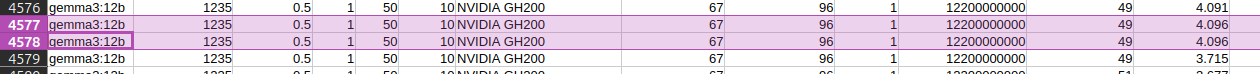

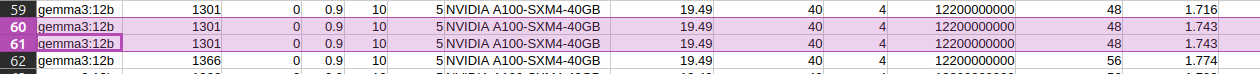

In [ ]:
#to make sure there is no more duplicated observations.
print(data2.duplicated().sum())

0


# 2 Features analysis

# 2.1 Features overview

## 2.1.1 Distribution of each numeric feature (Histogram)

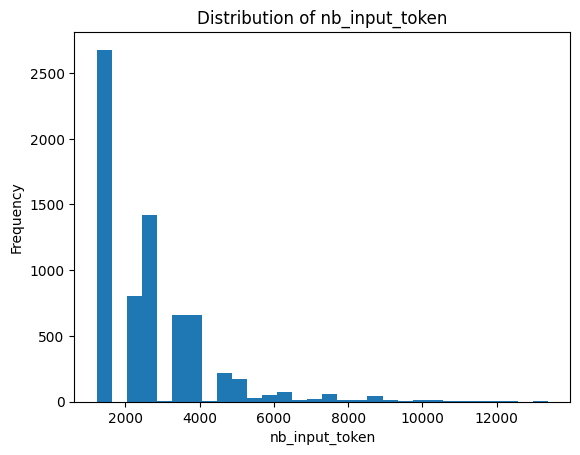

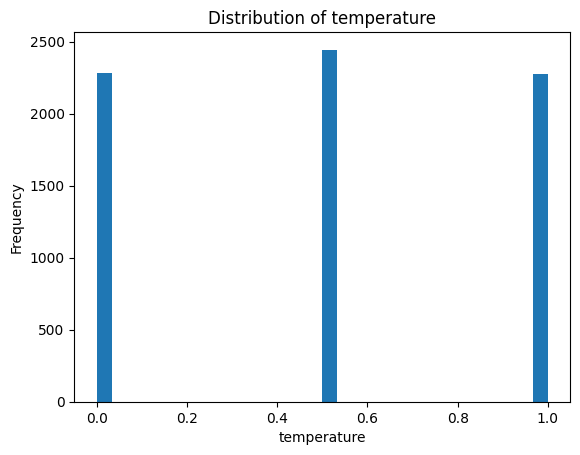

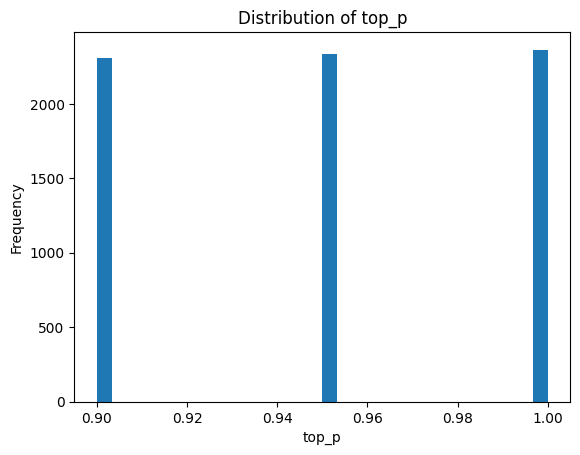

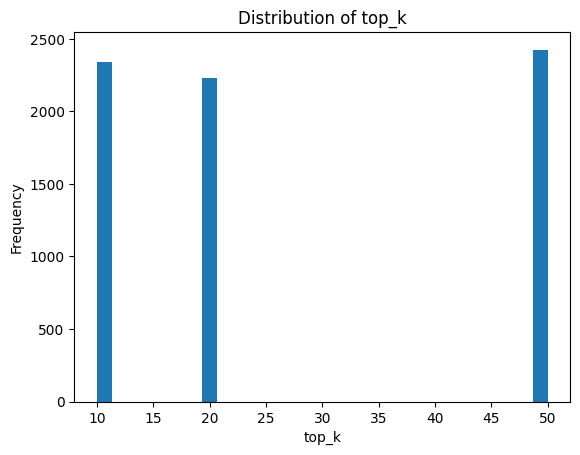

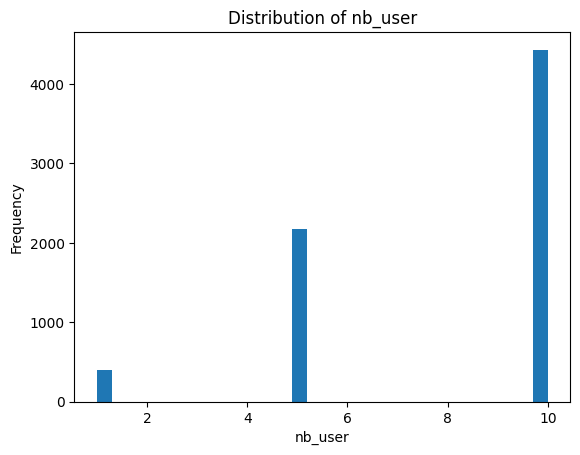

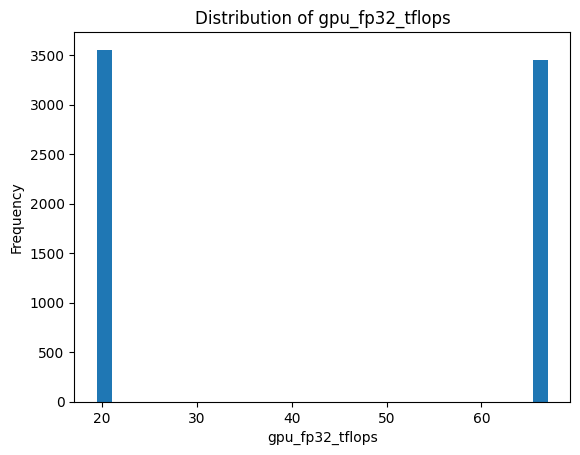

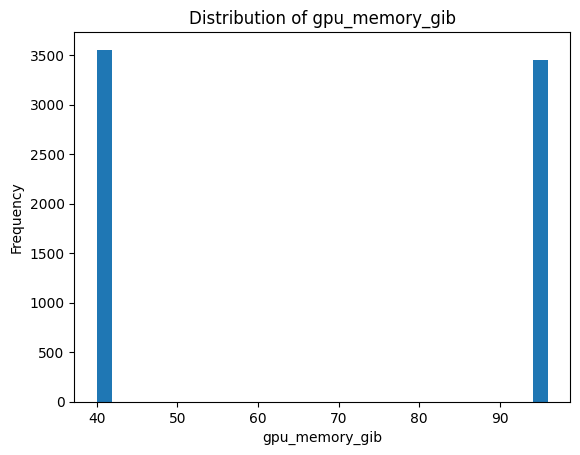

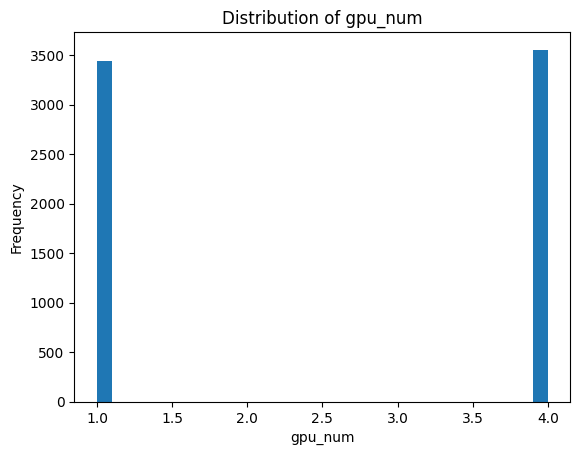

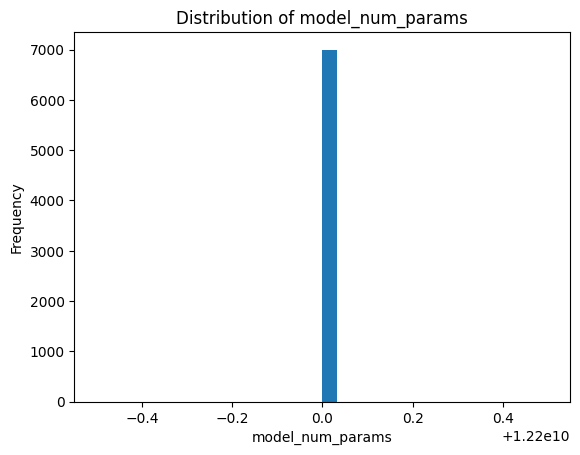

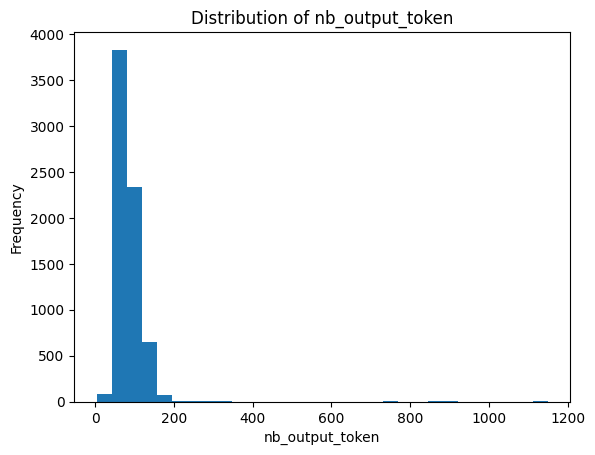

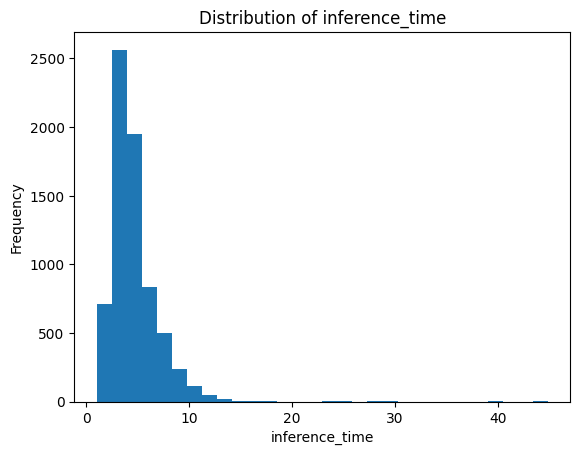

In [ ]:
num_cols = data2.select_dtypes(include=['number']).columns

for col in num_cols:
    plt.figure()
    plt.hist(data2[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

### 2.1.2 Outliers per feature (Boxplot)

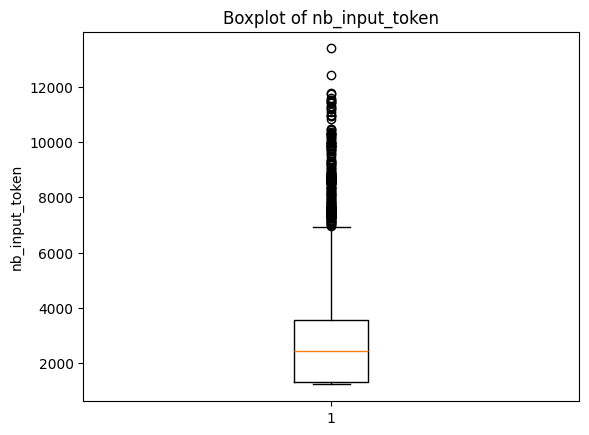

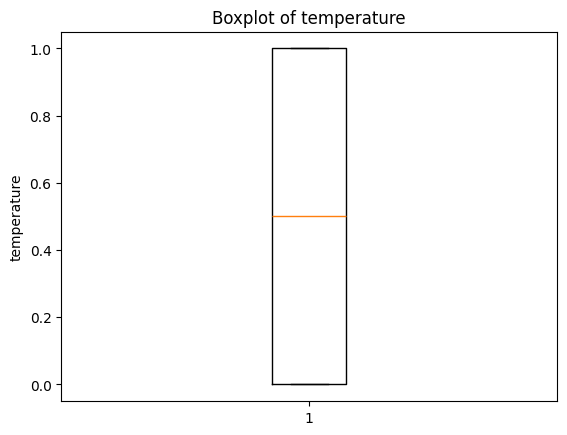

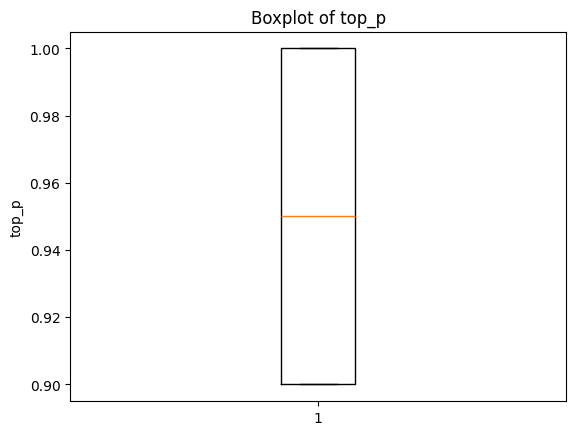

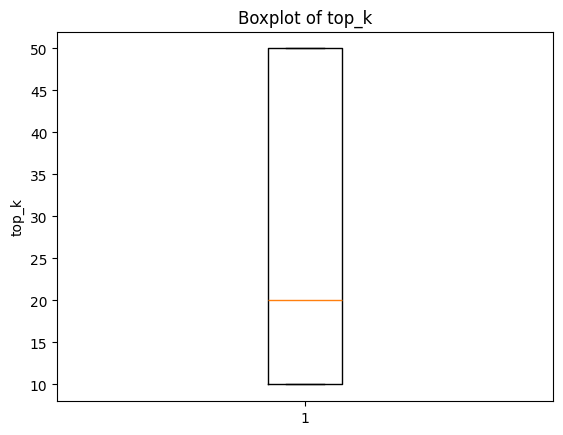

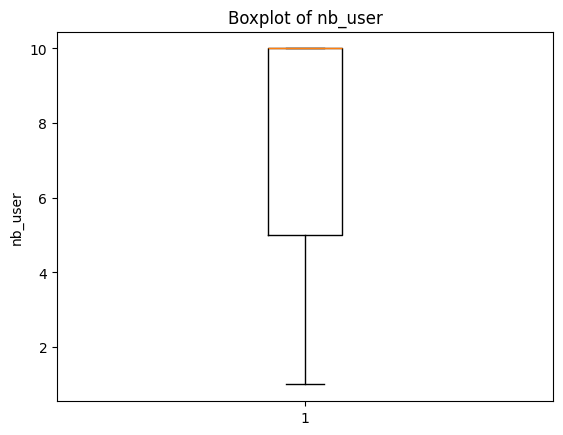

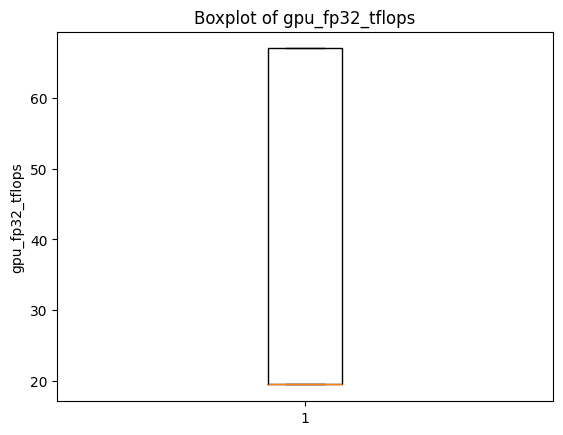

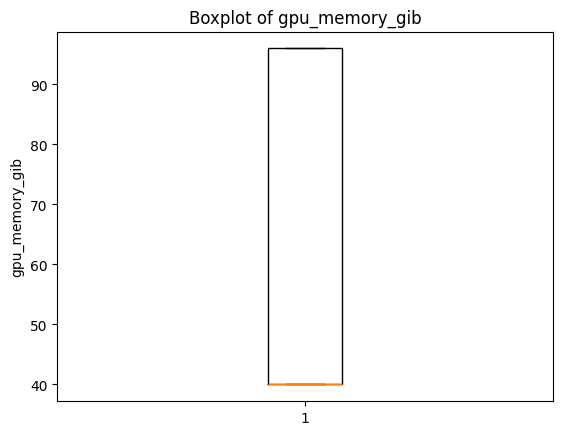

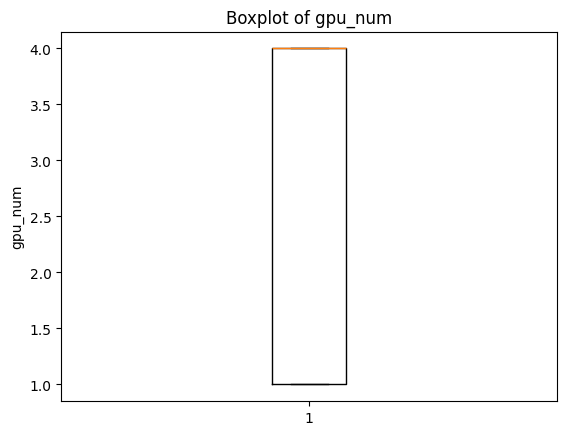

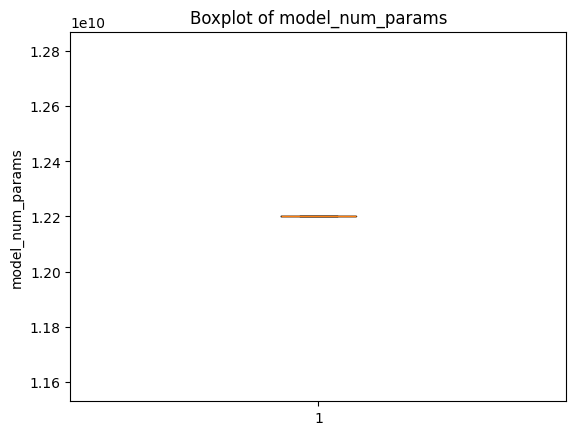

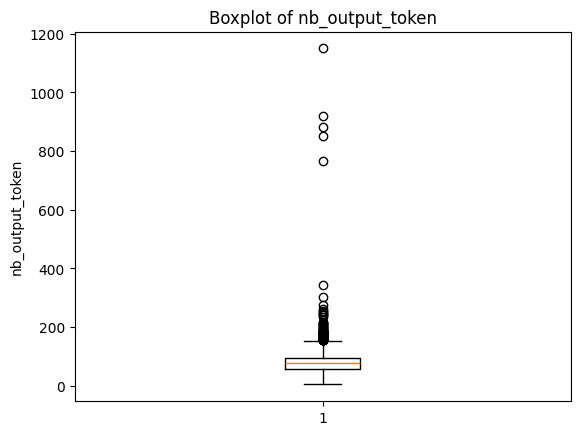

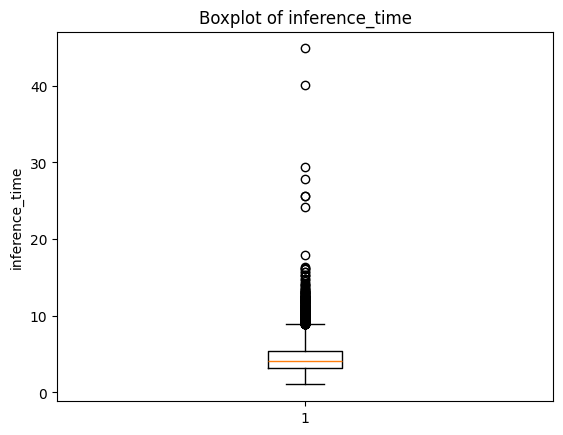

In [ ]:
for col in num_cols:
    plt.figure()
    plt.boxplot(data2[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

### 2.1.3 Distribution of each categorical feature

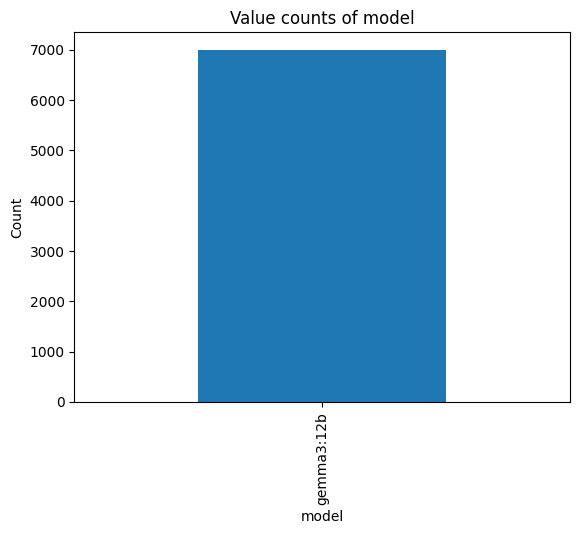

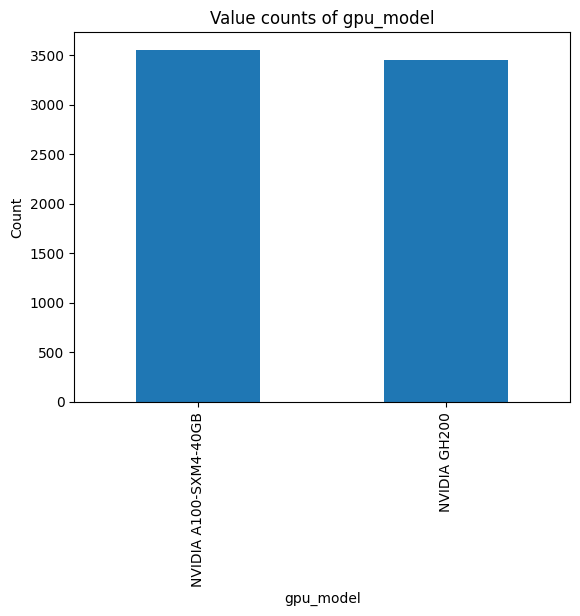

In [ ]:
cat_cols = data2.select_dtypes(include=['object']).columns
for col in cat_cols:
    plt.figure()
    data2[col].value_counts().plot(kind='bar')
    plt.title(f"Value counts of {col}")
    plt.ylabel("Count")
    plt.show()

## 2.2 Features processing

In [ ]:
(data2["model"] == "gemma3:12b").sum()

np.int64(7000)

In [ ]:
(data2["model_num_params"] == 12200000000).sum()

np.int64(7000)

The column model and model_num_params will be removed from the dataset because all 7000 observations have the same value which is gemma3:12b for model and 12200000000 for model_num_params.

In [ ]:
data3 = data2.drop(columns=["model"])
data3 = data3.drop(columns =["model_num_params"])
data3.shape

(7000, 11)

Currently the dataset contains 11 features and 7000 observations.

Using one hot encoding to convert gpu_model into numerical variable, because one hot encoding does not fake ordering.

In [ ]:
data3 = pd.get_dummies(data3, columns=["gpu_model"])
data3.shape

(7000, 12)

In [ ]:
data3.dtypes

,0
nb_input_token,int64
temperature,float64
top_p,float64
top_k,int64
nb_user,int64
gpu_fp32_tflops,float64
gpu_memory_gib,float64
gpu_num,int64
nb_output_token,int64
inference_time,float64


The target is inference_time.

In [ ]:
target = data3["inference_time"]

# 3. Features selection

## Recursive Feature Elimination with linear regression to select features

Recursive Feature Elimination (RFE) is a feature selection method used to identify the most relevant subset of features for predicting inference time. Linear regression is used as the underlying estimator because RFE relies on model based importance measures, such as coefficients, to rank and iteratively remove features. In contrast, Knn is not suitable for RFE because it does not produce explicit feature importance or coefficients.


### 3.1 What is the best set of if output length is already known?

In [ ]:
data3.info()
XrfeWithOutPutToken = data3.drop(columns=["inference_time"])
XrfeWithOutPutToken_train, XrfeWithOutPutToken_test, target_trainRfeWithOutPutToken, target_testRfeWithOutPutToken = train_test_split(
    XrfeWithOutPutToken, target, test_size=0.2, random_state=42
)

<class 'pandas.core.frame.DataFrame'>
Index: 7000 entries, 0 to 7015
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   nb_input_token                   7000 non-null   int64  
 1   temperature                      7000 non-null   float64
 2   top_p                            7000 non-null   float64
 3   top_k                            7000 non-null   int64  
 4   nb_user                          7000 non-null   int64  
 5   gpu_fp32_tflops                  7000 non-null   float64
 6   gpu_memory_gib                   7000 non-null   float64
 7   gpu_num                          7000 non-null   int64  
 8   nb_output_token                  7000 non-null   int64  
 9   inference_time                   7000 non-null   float64
 10  gpu_model_NVIDIA A100-SXM4-40GB  7000 non-null   bool   
 11  gpu_model_NVIDIA GH200           7000 non-null   bool   
dtypes: bool(2), float64(5), i

In [ ]:
cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)

best_score_RfeWithOutPutToken = float("inf")
best_k_RfeWithOutPutToken = None
best_features_RfeWithOutPutToken = None
best_pipeline_RfeWithOutPutToken = None

for k_RfeWithOutPutToken in range(1, XrfeWithOutPutToken_train.shape[1] + 1):

    selector_RfeWithOutPutToken = RFE(
        estimator=LinearRegression(),
        n_features_to_select=k_RfeWithOutPutToken
    )

    pipeline_RfeWithOutPutToken = Pipeline([
        ("scaler", StandardScaler()),
        ("rfe", selector_RfeWithOutPutToken),
        ("model", LinearRegression())
    ])

    scores_RfeWithOutPutToken = cross_val_score(
        pipeline_RfeWithOutPutToken,
        XrfeWithOutPutToken_train,
        target_trainRfeWithOutPutToken,
        scoring="neg_mean_absolute_error",
        cv=cv,
        n_jobs=-1
    )

    mae_RfeWithOutPutToken = -mean(scores_RfeWithOutPutToken)

    if mae_RfeWithOutPutToken < best_score_RfeWithOutPutToken:

        best_score_RfeWithOutPutToken = mae_RfeWithOutPutToken
        best_k_RfeWithOutPutToken = k_RfeWithOutPutToken

        pipeline_RfeWithOutPutToken.fit(
            XrfeWithOutPutToken_train,
            target_trainRfeWithOutPutToken
        )

        best_pipeline_RfeWithOutPutToken = pipeline_RfeWithOutPutToken

        best_selectorWithOutPutToken = pipeline_RfeWithOutPutToken.named_steps["rfe"]

        best_features_RfeWithOutPutToken = XrfeWithOutPutToken_train.columns[
            best_selectorWithOutPutToken.support_
        ]

print("Best MAE :", best_score_RfeWithOutPutToken)
print("Best number of features :", best_k_RfeWithOutPutToken)
print("Selected features :", best_features_RfeWithOutPutToken)

Best MAE : 1.0848300478610324
Best number of features : 9
Selected features : Index(['temperature', 'top_p', 'nb_user', 'gpu_fp32_tflops', 'gpu_memory_gib',
       'gpu_num', 'nb_output_token', 'gpu_model_NVIDIA A100-SXM4-40GB',
       'gpu_model_NVIDIA GH200'],
      dtype='object')


nb_output_token is selected because LLM generation is autoregressive: the model generates tokens one by one. So the more output tokens there are, the more decoding steps are needed. So it impacts inference time, but it is unkown before inference.

nb_input_token is not selected because inference_time ≈ prefill time + decoding time. nb_input_token mainly affects prefill, when the model reads the prompt, and nb_output_token mainly affects decoding, when the model generates the answer. When nb_output_token is already available, it directly explains a large part of the generation cost. So nb_input_token adds less extra information for the RFE algorithm. So input length does not improve the prediction enough to be selected.

top_k is not selected because it controls sampling, meaning how tokens are selected during generation. But it does not directly change the main computational cost as much as output length, user load, or hardware. So RFE removes it because it gives little additional predictive improvement.

GPU variables are selected because hardware affects inference time. However, the GPU variables are strongly correlated because they describe the same hardware setup in different ways: GPU model identity and GPU specifications.

### 3.2 RFE without nb_output_token (realistic RFE).

In [ ]:
dataWithoutOutPutToken = data3.drop(columns=["nb_output_token"])
dataWithoutOutPutToken.shape
dataWithoutOutPutToken.info()
XrfeWithoutOutPutToken = dataWithoutOutPutToken.drop(columns=["inference_time"])
XrfeWithoutOutPutToken_train, XrfeWithoutOutPutToken_test, target_trainRfeWithoutOutPutToken, target_testRfeWithoutOutPutToken = train_test_split(
    XrfeWithoutOutPutToken, target, test_size=0.2, random_state=42
)

<class 'pandas.core.frame.DataFrame'>
Index: 7000 entries, 0 to 7015
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   nb_input_token                   7000 non-null   int64  
 1   temperature                      7000 non-null   float64
 2   top_p                            7000 non-null   float64
 3   top_k                            7000 non-null   int64  
 4   nb_user                          7000 non-null   int64  
 5   gpu_fp32_tflops                  7000 non-null   float64
 6   gpu_memory_gib                   7000 non-null   float64
 7   gpu_num                          7000 non-null   int64  
 8   inference_time                   7000 non-null   float64
 9   gpu_model_NVIDIA A100-SXM4-40GB  7000 non-null   bool   
 10  gpu_model_NVIDIA GH200           7000 non-null   bool   
dtypes: bool(2), float64(5), int64(4)
memory usage: 560.5 KB


In [ ]:
cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)

best_score_RfeWithoutOutPutToken = float("inf")
best_k_RfeWithoutOutPutToken = None
best_features_RfeWithoutOutPutToken = None
best_pipeline_RfeWithoutOutPutToken = None

for k_RfeWithoutOutPutToken in range(1, XrfeWithoutOutPutToken_train.shape[1] + 1):

    selector_RfeWithoutOutPutToken = RFE(
        estimator=LinearRegression(),
        n_features_to_select=k_RfeWithoutOutPutToken
    )

    pipeline_RfeWithoutOutPutToken = Pipeline([
        ("scaler", StandardScaler()),
        ("rfe", selector_RfeWithoutOutPutToken),
        ("model", LinearRegression())
    ])

    scores_RfeWithoutOutPutToken = cross_val_score(
        pipeline_RfeWithoutOutPutToken,
        XrfeWithoutOutPutToken_train,
        target_trainRfeWithoutOutPutToken,
        scoring="neg_mean_absolute_error",
        cv=cv,
        n_jobs=-1
    )

    mae_RfeWithoutOutPutToken = -mean(scores_RfeWithoutOutPutToken)

    if mae_RfeWithoutOutPutToken < best_score_RfeWithoutOutPutToken:

        best_score_RfeWithoutOutPutToken = mae_RfeWithoutOutPutToken
        best_k_RfeWithoutOutPutToken = k_RfeWithoutOutPutToken

        pipeline_RfeWithoutOutPutToken.fit(
            XrfeWithoutOutPutToken_train,
            target_trainRfeWithoutOutPutToken
        )

        best_pipeline_RfeWithoutOutPutToken = pipeline_RfeWithoutOutPutToken

        best_selectorWithoutOutPutToken = pipeline_RfeWithoutOutPutToken.named_steps["rfe"]

        best_features_RfeWithoutOutPutToken = XrfeWithoutOutPutToken_train.columns[
            best_selectorWithoutOutPutToken.support_
        ]

print("Best MAE :", best_score_RfeWithoutOutPutToken)
print("Best number of features :", best_k_RfeWithoutOutPutToken)
print("Selected features :", best_features_RfeWithoutOutPutToken)

Best MAE : 1.2958725661123878
Best number of features : 5
Selected features : Index(['nb_input_token', 'nb_user', 'gpu_fp32_tflops', 'gpu_memory_gib',
       'gpu_num'],
      dtype='object')


The MAE increases 1.0848 → 1.2959 because we removed the strongest predictor: nb_output_token.

nb_input_token becomes selected now because when nb_output_token is removed, the model loses the direct information about generation length. Then nb_input_token carries indirect information about it. longer input → more prefill computation, possibly more complex request and sometimes related to longer responses. So it acts as a proxy for the missing output-length information.

temperature, top_p, and top_k disappear because they may influence the generated text, but their effect on inference time is indirect. For example, they may change output length or response structure, but if output length is unknown and not included, linear RFE may not capture that indirect relationship well.

GPU model indicators disappear because the GPU model indicators and GPU specifications contain redundant information. So RFE preferred the numerical hardware specifications because they directly represent the hardware capacity.

So RFE keeps the variables that are more directly related to computation

# 4. Correlation between features.

## 4.1 Correlation matrix

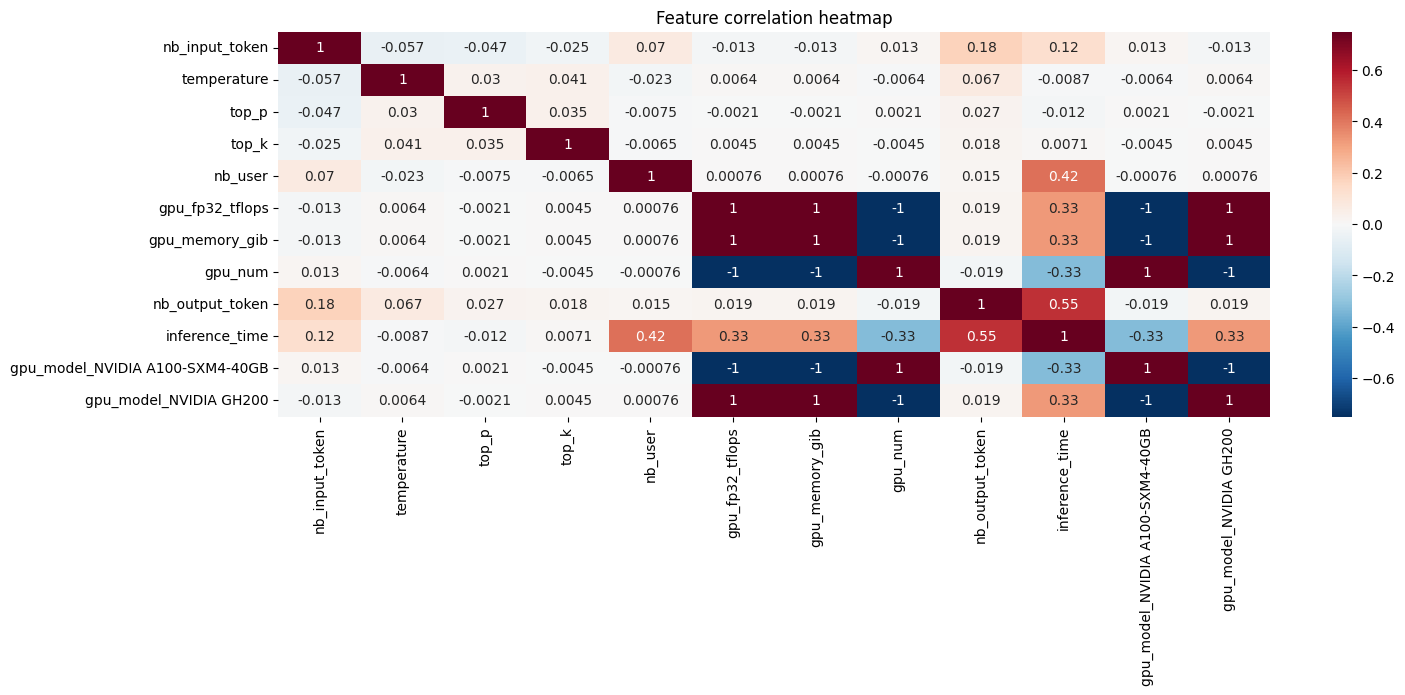

In [ ]:
corr = data3.corr(numeric_only=True)

plt.figure(figsize=(16, 5))
heatmap = sns.heatmap(corr, annot=True, linewidths=0, vmin=-0.75, vmax=0.75, cmap="RdBu_r")

plt.title("Feature correlation heatmap")
plt.show()

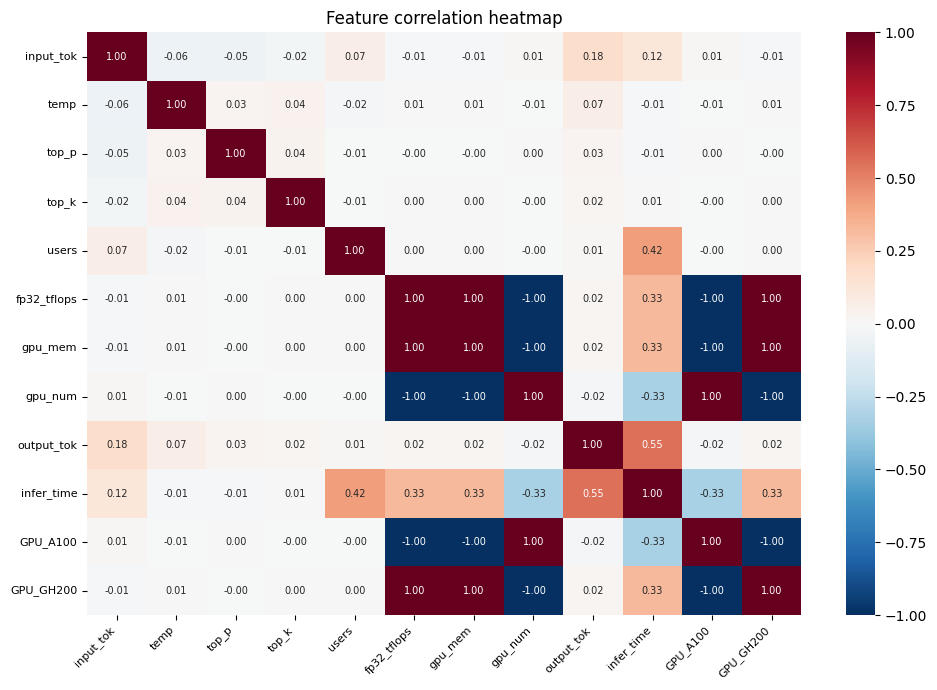

In [ ]:
corr = data3.corr(numeric_only=True)

short_names = {
    "nb_input_token": "input_tok",
    "temperature": "temp",
    "top_p": "top_p",
    "top_k": "top_k",
    "nb_user": "users",
    "gpu_fp32_tflops": "fp32_tflops",
    "gpu_memory_gib": "gpu_mem",
    "gpu_num": "gpu_num",
    "model_num_params": "model_params",
    "nb_output_token": "output_tok",
    "inference_time": "infer_time",
    "gpu_model_NVIDIA GH200": "GPU_GH200",
    "gpu_model_NVIDIA A100-SXM4-40GB": "GPU_A100"
}

corr_short = corr.rename(index=short_names, columns=short_names)

plt.figure(figsize=(10, 7))

heatmap = sns.heatmap(
    corr_short,
    annot=True,
    fmt=".2f",
    linewidths=0,
    vmin=-1,
    vmax=1,
    cmap="RdBu_r",
    annot_kws={"size": 7}
)

plt.title("Feature correlation heatmap")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig("corr.png", dpi=300, bbox_inches="tight")
plt.show()

the dataset shows a strong multicollinearity structure among gpu related features, where gpu memory, computational power, and model encoding variables are perfectly or inversely correlated, indicating they represent a single underlying factor describing hardware capability. Inference time is mainly influenced by workload related variables, especially the number of output tokens and user load. Sampling parameters such as temperature, top-p, and top-k show negligible linear correlation with inference time, suggesting their impact is either nonlinear or indirect.

The gpu-related features describe the same hardware information in two different ways :  

*   The GPU model identity features : gpu_model_NVIDIA A100-SXM4-40GB and gpu_model_NVIDIA GH200.
*   The GPU hardware specification features : gpu_memory_gib, gpu_num and gpu_fp32_tflops.

Since these variables were strongly correlated and gpu_model variables only give the name of the GPU, for example NVIDIA GH200 or NVIDIA A100-SXM4-40GB. We will only keep the The GPU hardware specification features because they describe the hardware capacity of the GPU setup :


*   gpu_fp32_tflops : computational capability
*   gpu_memory_gib  : available GPU memory
*   gpu_num         : number of GPUs used


So they are more meaningful for the prediction problem, because LLM inference time depends on hardware resources: how much computation the GPU can perform, how much memory is available, and how many GPUs are used.

## 4.2 Recursive Feature Elimination (after removing gpu_model_NVIDIA A100-SXM4-40GB and gpu_model_NVIDIA GH200 and if we have nb_output_token)

In [ ]:
dataWithoutGpuModel = data3.drop(columns=['gpu_model_NVIDIA GH200', 'gpu_model_NVIDIA A100-SXM4-40GB'])
dataWithoutGpuModel.shape
dataWithoutGpuModel.info()
XrfeWithoutGpuModel = dataWithoutGpuModel.drop(columns=["inference_time"])
XrfeWithoutGpuModel_train, XrfeWithoutGpuModel_test, target_trainRfeWithoutGpuModel, target_testRfeWithoutGpuModel = train_test_split(
    XrfeWithoutGpuModel, target, test_size=0.2, random_state=42
)

<class 'pandas.core.frame.DataFrame'>
Index: 7000 entries, 0 to 7015
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   nb_input_token   7000 non-null   int64  
 1   temperature      7000 non-null   float64
 2   top_p            7000 non-null   float64
 3   top_k            7000 non-null   int64  
 4   nb_user          7000 non-null   int64  
 5   gpu_fp32_tflops  7000 non-null   float64
 6   gpu_memory_gib   7000 non-null   float64
 7   gpu_num          7000 non-null   int64  
 8   nb_output_token  7000 non-null   int64  
 9   inference_time   7000 non-null   float64
dtypes: float64(5), int64(5)
memory usage: 601.6 KB


In [ ]:
cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)

best_score_RfeWithoutGpuModel = float("inf")
best_k_RfeWithoutGpuModel = None
best_features_RfeWithoutGpuModel = None
best_pipeline_RfeWithoutGpuModel = None

for k_RfeWithoutGpuModel in range(1, XrfeWithoutGpuModel_train.shape[1] + 1):

    selector_RfeWithoutGpuModel = RFE(
        estimator=LinearRegression(),
        n_features_to_select=k_RfeWithoutGpuModel
    )

    pipeline_RfeWithoutGpuModel = Pipeline([
        ("scaler", StandardScaler()),
        ("rfe", selector_RfeWithoutGpuModel),
        ("model", LinearRegression())
    ])

    scores_RfeWithoutGpuModel = cross_val_score(
        pipeline_RfeWithoutGpuModel,
        XrfeWithoutGpuModel_train,
        target_trainRfeWithoutGpuModel,
        scoring="neg_mean_absolute_error",
        cv=cv,
        n_jobs=-1
    )

    mae_RfeWithoutGpuModel = -mean(scores_RfeWithoutGpuModel)

    if mae_RfeWithoutGpuModel < best_score_RfeWithoutGpuModel:

        best_score_RfeWithoutGpuModel = mae_RfeWithoutGpuModel
        best_k_RfeWithoutGpuModel = k_RfeWithoutGpuModel

        pipeline_RfeWithoutGpuModel.fit(
            XrfeWithoutGpuModel_train,
            target_trainRfeWithoutGpuModel
        )

        best_pipeline_RfeWithoutGpuModel = pipeline_RfeWithoutGpuModel

        best_selectorWithoutGpuModel = pipeline_RfeWithoutGpuModel.named_steps["rfe"]

        best_features_RfeWithoutGpuModel = XrfeWithoutGpuModel_train.columns[
            best_selectorWithoutGpuModel.support_
        ]

print("Best MAE :", best_score_RfeWithoutGpuModel)
print("Best number of features :", best_k_RfeWithoutGpuModel)
print("Selected features :", best_features_RfeWithoutGpuModel)

Best MAE : 1.0848300478610324
Best number of features : 7
Selected features : Index(['temperature', 'top_p', 'nb_user', 'gpu_fp32_tflops', 'gpu_memory_gib',
       'gpu_num', 'nb_output_token'],
      dtype='object')


## 4.3 Conclusion

We will use these feature for the oracle/irrealistic model (with nb_output_token) : temperature, top_p, nb_user, gpu_fp32_tflops, gpu_memory_gib, gpu_num, nb_output_token.

For the realistic model (without nb_output_token), the features will use are : nb_input_token, nb_user, gpu_fp32_tflops, gpu_memory_gib, gpu_num.

 # 5. P-value

The p-value is a statistical measure that will test whether a feature has a non-zero linear association with inference time, given the other features in the model.

## 5.1 P-value with cleaned oracle feature set

If output length is already known, which variables are linearly associated with inference time ?

In [ ]:
X_pvalue_oracle = XrfeWithoutGpuModel_train.astype(float)
X_pvalue_oracle = sm.add_constant(X_pvalue_oracle)

model_pvalue_oracle = sm.OLS(
    target_trainRfeWithoutGpuModel,
    X_pvalue_oracle
).fit()

print(model_pvalue_oracle.summary())

                            OLS Regression Results                            
Dep. Variable:         inference_time   R-squared:                       0.558
Model:                            OLS   Adj. R-squared:                  0.557
Method:                 Least Squares   F-statistic:                     1008.
Date:                Wed, 03 Jun 2026   Prob (F-statistic):               0.00
Time:                        14:28:45   Log-Likelihood:                -10176.
No. Observations:                5600   AIC:                         2.037e+04
Df Residuals:                    5592   BIC:                         2.042e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.0062      0.003     

The cleaned oracle feature set explains about 55.8% of the variance in inference time on the training set. This means that the multiple linear regression model captures a meaningful part of the variability in inference time, but not all of it. Therefore, inference time is only partly explained by a linear additive relationship.

The value Prob(F-statistic) = 0.00 means that the model as a whole is statistically significant. In other words, at least one feature has a non-zero linear association with inference_time.

nb_output_token is strongly significant, with a p-value equal to 0.000. Its coefficient is about 0.0323, which means that each additional generated output token is associated with an increase of about 0.032 seconds in inference time, while keeping the other variables fixed. This confirms that nb_output_token is a dominant predictor, because generating more output tokens requires more decoding steps.

nb_user is also statistically significant, with a p-value equal to 0.000. Its coefficient is positive, about 0.3221, meaning that increasing the number of users is associated with higher inference time. This is logical because more users create more concurrent load, more scheduling pressure, and potentially more waiting or resource contention.

temperature is statistically significant, with a p-value equal to 0.000. In this linear model, higher temperature is associated with slightly lower inference time, after controlling for the other variables. However, this result should be interpreted carefully, because temperature mainly affects the sampling behavior and may reflect indirect generation effects rather than a direct computational cost. Also, since the training set contains 5600 observations, even small effects can become statistically significant.

top_p is also significant, with a p-value equal to 0.025. Its coefficient is about -1.0910, meaning that an increase of 0.1 in top_p corresponds approximately to a decrease of 0.109 seconds in inference time, while holding the other variables fixed. However, this effect is smaller than the effects of nb_output_token and nb_user.

nb_input_token and top_k are not statistically significant in this model, with p-values equal to 0.911 and 0.693. This means that, when nb_output_token is already included, these variables do not add a clear independent linear contribution to inference time. This is coherent with the RFE result, because RFE later removed nb_input_token and top_k.

The value Df Model = 7 appears even though there are more input variables, because some variables are linearly dependent. This is mainly due to the GPU hardware variables, which describe the same hardware configuration in different ways. This confirms the presence of multicollinearity.

## 5.2 P-value with cleaned realistic feature set

When output length is unknown, which available features still explain inference time?

In [ ]:
dataWithoutGpuModelandOutputToken = data3.drop(columns=["gpu_model_NVIDIA GH200", "gpu_model_NVIDIA A100-SXM4-40GB", "nb_output_token"])

XWithoutGpuModelandOutputToken = dataWithoutGpuModelandOutputToken.drop(columns=["inference_time"])
targetWithoutGpuModelandOutputToken = dataWithoutGpuModelandOutputToken["inference_time"]

XWithoutGpuModelandOutputToken_train, XWithoutGpuModelandOutputToken_test, target_trainWithoutGpuModelandOutputToken, target_testWithoutGpuModelandOutputToken = train_test_split(
    XWithoutGpuModelandOutputToken,
    targetWithoutGpuModelandOutputToken,
    test_size=0.2,
    random_state=42
)

X_pvalue_without_output = XWithoutGpuModelandOutputToken_train.astype(float)
X_pvalue_without_output = sm.add_constant(X_pvalue_without_output)

model_pvalue_without_output = sm.OLS(
    target_trainWithoutGpuModelandOutputToken,
    X_pvalue_without_output
).fit()

print(model_pvalue_without_output.summary())

                            OLS Regression Results                            
Dep. Variable:         inference_time   R-squared:                       0.292
Model:                            OLS   Adj. R-squared:                  0.291
Method:                 Least Squares   F-statistic:                     383.8
Date:                Wed, 03 Jun 2026   Prob (F-statistic):               0.00
Time:                        14:28:46   Log-Likelihood:                -11496.
No. Observations:                5600   AIC:                         2.301e+04
Df Residuals:                    5593   BIC:                         2.305e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0012      0.004     

In the realistic setting without nb_output_token, the model explains only 29.2% of the variance in inference time. The significant variables are mainly nb_input_token and nb_user, showing that prompt length and user load are the strongest available linear predictors when output length is unknown. Decoding parameters do not show a significant independent linear effect in this model.

# Target informations

In [ ]:
print("Mean inference time:", target_testRfeWithoutGpuModel.mean())
print("Median inference time:", target_testRfeWithoutGpuModel.median())
print("Min inference time:", target_testRfeWithoutGpuModel.min())
print("Max inference time:", target_testRfeWithoutGpuModel.max())
print("Q1 (25%):", target_testRfeWithoutGpuModel.quantile(0.25))
print("Q3 (75%):", target_testRfeWithoutGpuModel.quantile(0.75))

Mean inference time: 4.601453571428571
Median inference time: 4.0575
Min inference time: 1.186
Max inference time: 40.089
Q1 (25%): 3.15525
Q3 (75%): 5.4275


# **First model : Multiple linear regression**

## **1. Oracle model i.e. it uses nb_output_token that is unkown before inference.**

The first model is multiple linear regression. It is chosen because it is a strong baseline model for continuous prediction problems like inference time. It is fast to train, easy to interpret.

Features used : nb_input_token, temperature, top_p, top_k, nb_user, gpu_fp32_tflops, nb_output_token, gpu_memory_gib and gpu_num.

In [ ]:
selected_features_lr_with_output = [
    "temperature",
    "top_p",
    "nb_user",
    "gpu_fp32_tflops",
    "gpu_memory_gib",
    "gpu_num",
    "nb_output_token"
]

X_train_lr_with_output = XrfeWithoutGpuModel_train[selected_features_lr_with_output]
X_test_lr_with_output = XrfeWithoutGpuModel_test[selected_features_lr_with_output]

lr_with_output = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

lr_with_output.fit(
    X_train_lr_with_output,
    target_trainRfeWithoutGpuModel
)

pred_lr_with_output = lr_with_output.predict(X_test_lr_with_output)

mae_lr_with_output = mean_absolute_error(
    target_testRfeWithoutGpuModel,
    pred_lr_with_output
)

mse_lr_with_output = mean_squared_error(
    target_testRfeWithoutGpuModel,
    pred_lr_with_output
)

rmse_lr_with_output = np.sqrt(mse_lr_with_output)

r2_lr_with_output = r2_score(
    target_testRfeWithoutGpuModel,
    pred_lr_with_output
)

print("MAE of the linear model with nb_output_token:", mae_lr_with_output)
print("MSE of the linear model with nb_output_token:", mse_lr_with_output)
print("RMSE of the linear model with nb_output_token:", rmse_lr_with_output)
print("R2 of the linear model with nb_output_token:", r2_lr_with_output)

MAE of the linear model with nb_output_token: 1.0679998362941558
MSE of the linear model with nb_output_token: 2.1729734157701293
RMSE of the linear model with nb_output_token: 1.4741008838509424
R2 of the linear model with nb_output_token: 0.612560786055741


The model explains about 61.3% of the variance in inference time. This is a reasonable result, but not excellent. It means the linear model captures part of the relationship between the selected features and inference time, but a large part of the variability remains unexplained.

The MAE is about 1.07 seconds. Since the median inference time is about 4.08 seconds, this means the average error is around 26% of a typical request duration. So the model gives useful predictions, but the error is still important compared with normal inference times.

The RMSE is about 1.47 seconds, which is higher than the MAE. This means that the model makes some larger errors, especially on difficult or extreme observations.

### 1.1 Actual vs predicted (with nb_output_token)

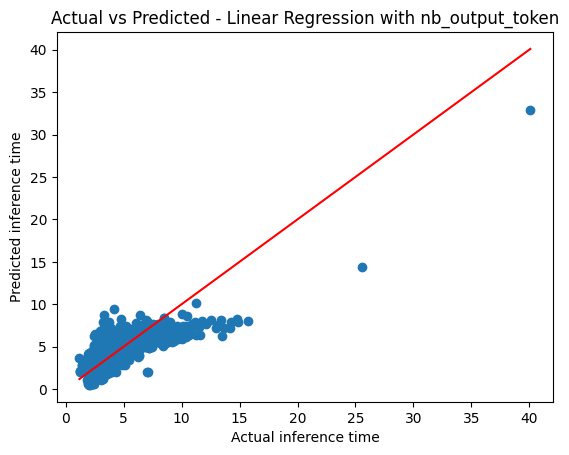

In [ ]:
plt.scatter(target_testRfeWithoutGpuModel, pred_lr_with_output)

plt.plot(
    [target_testRfeWithoutGpuModel.min(), target_testRfeWithoutGpuModel.max()],
    [target_testRfeWithoutGpuModel.min(), target_testRfeWithoutGpuModel.max()],
    color="red"
)

plt.xlabel("Actual inference time")
plt.ylabel("Predicted inference time")
plt.title("Actual vs Predicted - Linear Regression with nb_output_token")
plt.show()

Most points are in the common inference-time range, between about 2 and 10 seconds. The model follows the general trend, but many predictions are compressed in a limited range and do not follow the red line perfectly.

For large actual inference times, especially around 25 to 40 seconds, the model predicts much smaller values. This means the linear regression model tends to underestimate extreme inference times.

### 1.2 Residual plot

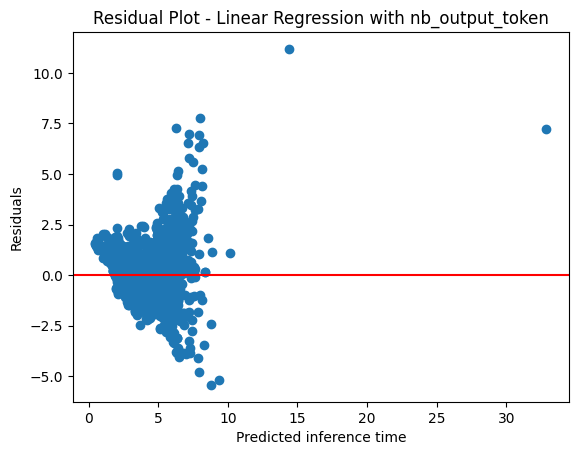

In [ ]:
residuals_lr_with_output = target_testRfeWithoutGpuModel - pred_lr_with_output

plt.scatter(pred_lr_with_output, residuals_lr_with_output)
plt.axhline(y=0, color="red")

plt.xlabel("Predicted inference time")
plt.ylabel("Residuals")
plt.title("Residual Plot - Linear Regression with nb_output_token")
plt.show()

The residuals are centered around zero for many observations, but the spread is not constant. The residuals become larger for higher predicted values, and some large positive residuals appear.

Since residual = actual - predicted, large positive residuals mean that the true inference time was much higher than predicted. This confirms that the linear model struggles with high-latency requests.

## **2. Realistic/deployable model i.e. it uses only features known before inference.**

Features used : nb_input_token, nb_user, gpu_fp32_tflops, gpu_memory_gib and gpu_num.

In [ ]:
selected_features_lr_without_output = [
    "nb_input_token",
    "nb_user",
    "gpu_fp32_tflops",
    "gpu_memory_gib",
    "gpu_num"
]

X_train_lr_without_output = XrfeWithoutOutPutToken_train[selected_features_lr_without_output]
X_test_lr_without_output = XrfeWithoutOutPutToken_test[selected_features_lr_without_output]

target_train_lr_without_output = target_trainRfeWithoutOutPutToken
target_test_lr_without_output = target_testRfeWithoutOutPutToken

lr_without_output = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

lr_without_output.fit(
    X_train_lr_without_output,
    target_train_lr_without_output
)

pred_lr_without_output = lr_without_output.predict(
    X_test_lr_without_output
)

mae_lr_without_output = mean_absolute_error(
    target_test_lr_without_output,
    pred_lr_without_output
)

mse_lr_without_output = mean_squared_error(
    target_test_lr_without_output,
    pred_lr_without_output
)

rmse_lr_without_output = np.sqrt(mse_lr_without_output)

r2_lr_without_output = r2_score(
    target_test_lr_without_output,
    pred_lr_without_output
)

print("MAE of the linear model without nb_output_token:", mae_lr_without_output)
print("MSE of the linear model without nb_output_token:", mse_lr_without_output)
print("RMSE of the linear model without nb_output_token:", rmse_lr_without_output)
print("R2 of the linear model without nb_output_token:", r2_lr_without_output)

MAE of the linear model without nb_output_token: 1.315554225365866
MSE of the linear model without nb_output_token: 4.028215371841252
RMSE of the linear model without nb_output_token: 2.0070414474647134
R2 of the linear model without nb_output_token: 0.2817728068195312


The model explains about 28.2% of the variance in inference time. This is a relatively low value, meaning that the selected features known before inference only explain a limited part of the variability. This is expected because nb_output_token, which is one of the strongest predictors, is not available in this realistic setting.

The MAE is 1.32 seconds, meaning that on average the model is off by about 1.32 seconds. Since the median inference time is about 4.08 seconds, this error represents around 32% of a typical request duration. So the error is not negligible.

The RMSE is 2.01 seconds, which is higher than the MAE. This means that the model makes some large errors, especially for extreme inference-time values. Since MSE and RMSE penalize large errors more strongly, this confirms that the model struggles with some difficult observations.

### 2.1 Actual vs predicted (without nb_output_token)

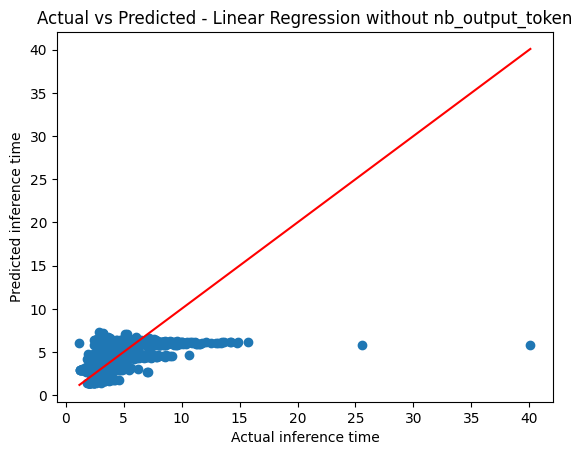

In [ ]:
plt.scatter(target_test_lr_without_output, pred_lr_without_output)

plt.plot(
    [target_test_lr_without_output.min(), target_test_lr_without_output.max()],
    [target_test_lr_without_output.min(), target_test_lr_without_output.max()],
    color="red"
)

plt.xlabel("Actual inference time")
plt.ylabel("Predicted inference time")
plt.title("Actual vs Predicted - Linear Regression without nb_output_token")
plt.show()

The actual vs predicted plot shows that predictions are compressed in a narrow range, mostly between about 2 and 7 seconds. This means the model does not predict very high inference times well.

For normal requests around 3 to 6 seconds, the model gives reasonable approximate predictions. However, for large actual inference times, for example around 25 to 40 seconds, the predicted values remain around 6 seconds. So the model strongly underestimates extreme inference times.

This shows that the linear regression model without nb_output_token cannot capture high-latency cases properly.

### 2.2 Residuals vs Predicted

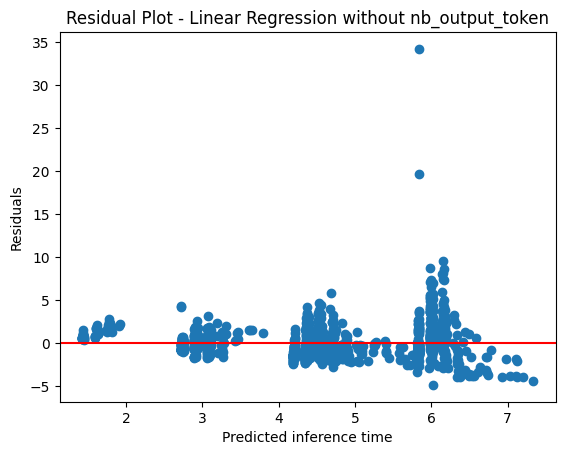

In [ ]:
residuals_lr_without_output = target_test_lr_without_output - pred_lr_without_output

plt.scatter(pred_lr_without_output, residuals_lr_without_output)
plt.axhline(0, color="red")

plt.xlabel("Predicted inference time")
plt.ylabel("Residuals")
plt.title("Residual Plot - Linear Regression without nb_output_token")
plt.show()

The residual plot confirms this behavior. Most residuals are around zero for common predictions, but there are some very large positive residuals. The residuals also show a structured pattern instead of a random cloud around zero. This suggests that the linear model does not fully capture the relationship between the selected features and inference time. It may be missing important information, especially output length, or nonlinear effects.

## **3. Linearity between inference time and the other features.**

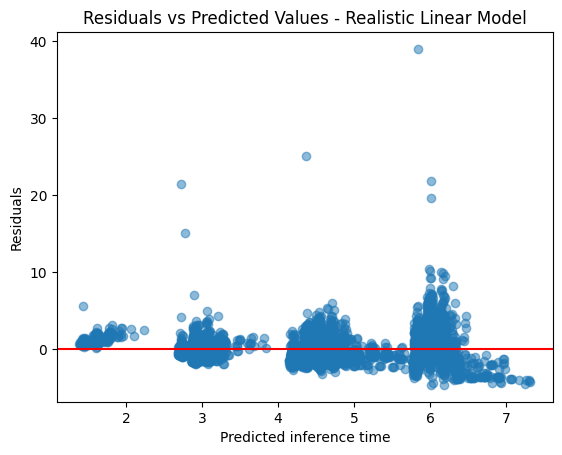

In [ ]:
X_linear = XWithoutGpuModelandOutputToken_train.astype(float)
target_linear = target_trainWithoutGpuModelandOutputToken

X_linear_const = sm.add_constant(X_linear)

linear_model = sm.OLS(target_linear, X_linear_const).fit()

predicted_values = linear_model.fittedvalues
residuals = linear_model.resid

plt.scatter(predicted_values, residuals, alpha=0.5)
plt.axhline(y=0, color="red")
plt.xlabel("Predicted inference time")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values - Realistic Linear Model")
plt.show()

The residuals vs predicted values plot was used to check whether the linear regression assumption is reasonable. The residuals are not randomly distributed around zero, they show structured groups, changing spread, and several large positive residuals. This suggests that the realistic linear regression model does not fully capture the relationship between the available features and inference time. In particular, some high-latency observations are underestimated, probably because nb_output_token, a major predictor of generation cost, is not available before inference. And the relationship between the available features and inference time is probably not only linear and additive.

## 3.1 VIF for multicollinearity

VIF means Variance Inflation Factor. It measures whether one feature can be predicted from the other features.

- VIF ≈ 1      no multicollinearity
- VIF > 5      possible multicollinearity
- VIF > 10     strong multicollinearity
- VIF = inf    perfect multicollinearity

In [ ]:
vif_data = pd.DataFrame()
vif_data["feature"] = X_linear.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_linear.values, i)
    for i in range(X_linear.shape[1])
]

vif_data

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
0,nb_input_token,1.011754
1,temperature,1.007330
2,top_p,1.005211
3,top_k,1.004541
4,nb_user,1.005726
5,gpu_fp32_tflops,inf
6,gpu_memory_gib,inf
7,gpu_num,inf


- nb_input_token   VIF ≈ 1.01
-temperature      VIF ≈ 1.01
- top_p            VIF ≈ 1.00
- top_k            VIF ≈ 1.00
- nb_user          VIF ≈ 1.01

There is perfect multicollinearity between GPU hardware specification features. The other variables do not have a multicollinearity problem.

# **Second model : k-nearest neighbors for regression**

K-Nearest Neighbors is chosen because it does not assume any functional form between variables and can capture nonlinear and local patterns in the data.

## Sequential Feature Selection with KNN

RFE with linear regression ranks features using linear coefficients but KNN does not use coefficients it uses distance between observations. So a feature is useful for KNN if it improves the distance-based neighborhood structure. Sequential Feature Selection tests feature subsets using KNN, so the selected features are optimized for KNN performance.


→ train KNN

→ evaluate with CV

→ keep the subset that gives best KNN performance

In [ ]:
candidate_features_knn_with_output = [
    "nb_input_token",
    "temperature",
    "top_p",
    "top_k",
    "nb_user",
    "gpu_fp32_tflops",
    "gpu_memory_gib",
    "gpu_num",
    "nb_output_token"
]

X_train_knn_candidates = XrfeWithoutGpuModel_train[candidate_features_knn_with_output]
X_test_knn_candidates = XrfeWithoutGpuModel_test[candidate_features_knn_with_output]

target_train_knn = target_trainRfeWithoutGpuModel
target_test_knn = target_testRfeWithoutGpuModel

In [ ]:
knn_selector_estimator = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(
        n_neighbors=9,
        metric="euclidean",
        weights="distance"
    ))
])

best_score_sfs_knn = -np.inf
best_features_sfs_knn = None
best_number_features_sfs_knn = None

n_total_features = X_train_knn_candidates.shape[1]

for n_features in range(1, n_total_features):

    sfs_knn = SequentialFeatureSelector(
        estimator=knn_selector_estimator,
        n_features_to_select=n_features,
        direction="forward",
        scoring="r2",
        cv=10,
        n_jobs=-1
    )

    sfs_knn.fit(X_train_knn_candidates, target_train_knn)

    selected_features = X_train_knn_candidates.columns[sfs_knn.get_support()]

    scores = cross_val_score(
        knn_selector_estimator,
        X_train_knn_candidates[selected_features],
        target_train_knn,
        cv=10,
        scoring="r2",
        n_jobs=-1
    )

    mean_score = scores.mean()

    if mean_score > best_score_sfs_knn:
        best_score_sfs_knn = mean_score
        best_features_sfs_knn = selected_features
        best_number_features_sfs_knn = n_features

print("Best number of features for KNN:", best_number_features_sfs_knn)
print("Best features for KNN:", list(best_features_sfs_knn))
print("Best CV R2 for KNN feature selection:", best_score_sfs_knn)

Best number of features for KNN: 7
Best features for KNN: ['nb_input_token', 'temperature', 'nb_user', 'gpu_fp32_tflops', 'gpu_memory_gib', 'gpu_num', 'nb_output_token']
Best CV R2 for KNN feature selection: 0.7570958553223038


The important variables for KNN are:

- nb_output_token: dominant because output length directly affects decoding time
- nb_input_token: useful for prompt/prefill cost and request complexity
- nb_user: captures system load
- GPU hardware specification variables: capture hardware configuration
- temperature: may capture some generation behavior

top_p and top_k were removed because they control the sampling strategy, but they may not directly affect inference time as strongly as the other chosen features.

## 1. Oracle model i.e. it uses nb_output_token that is unkown before inference.

Features used : nb_input_token, temperature, nb_user, gpu_fp32_tflops, gpu_memory_gib, gpu_num, nb_output_token.

### 1.1 Cross validation

In [ ]:
selected_features_knn_rfe = [ "nb_input_token","temperature","nb_user","gpu_fp32_tflops","gpu_memory_gib","gpu_num","nb_output_token"]

X_rfe_train = XrfeWithoutGpuModel_train[selected_features_knn_rfe]
X_rfe_test = XrfeWithoutGpuModel_test[selected_features_knn_rfe]

y_rfe_train = target_trainRfeWithoutGpuModel
y_rfe_test = target_testRfeWithoutGpuModel

k_values = range(1, 21)

distances = ["euclidean","manhattan", "minkowski", "mahalanobis"]

cv = KFold(n_splits=10, shuffle=True, random_state=42)

best_score_knn_rfe = -np.inf
best_params_knn_rfe = None

for metric in distances:
    for k in k_values:

        fold_scores = []

        for train_idx, val_idx in cv.split(X_rfe_train):

            X_fold_train = X_rfe_train.iloc[train_idx]
            X_fold_val = X_rfe_train.iloc[val_idx]

            y_fold_train = y_rfe_train.iloc[train_idx]
            y_fold_val = y_rfe_train.iloc[val_idx]

            scaler = StandardScaler()

            X_fold_train_scaled = scaler.fit_transform(X_fold_train)
            X_fold_val_scaled = scaler.transform(X_fold_val)

            if metric == "mahalanobis":
                covariance_matrix = np.cov(X_fold_train_scaled, rowvar=False)
                inverse_covariance_matrix = np.linalg.pinv(covariance_matrix)

                model_knn_rfe = KNeighborsRegressor(
                    n_neighbors=k,
                    metric="mahalanobis",
                    metric_params={"VI": inverse_covariance_matrix},
                    weights="distance"
                )

            elif metric == "minkowski":
                model_knn_rfe = KNeighborsRegressor(
                    n_neighbors=k,
                    metric="minkowski",
                    p=3,
                    weights="distance"
                )

            else:
                model_knn_rfe = KNeighborsRegressor(
                    n_neighbors=k,
                    metric=metric,
                    weights="distance"
                )

            model_knn_rfe.fit(X_fold_train_scaled, y_fold_train)

            y_fold_pred = model_knn_rfe.predict(X_fold_val_scaled)

            fold_score = r2_score(y_fold_val, y_fold_pred)
            fold_scores.append(fold_score)

        mean_score = np.mean(fold_scores)

        if mean_score > best_score_knn_rfe:
            best_score_knn_rfe = mean_score
            best_params_knn_rfe = (k, metric)

print("Best params :", best_params_knn_rfe)
print("Best CV R2 :", best_score_knn_rfe)

Best params : (8, 'mahalanobis')
Best CV R2 : 0.7627297309862188


Euclidean and Manhattan distances were tested, but these distances treat features as if they were independent. In this dataset, some variables are strongly correlated, especially the GPU hardware variables such as gpu_fp32_tflops, gpu_memory_gib, and gpu_num. Therefore, Mahalanobis distance is relevant because it takes into account the correlation structure between features when computing distances.

Cross-validation selected Mahalanobis distance with k = 8 as the best configuration. This means that, among the tested distance metrics, Mahalanobis distance gave the best average R² score on the training folds. So it was not chosen manually but it was selected because it gave the best validation performance.

### 1.2 The creation of knn model

In [ ]:
best_k_rfe, best_metric_rfe = best_params_knn_rfe

scaler_knn_rfe = StandardScaler()

X_rfe_train_scaled = scaler_knn_rfe.fit_transform(X_rfe_train)
X_rfe_test_scaled = scaler_knn_rfe.transform(X_rfe_test)

if best_metric_rfe == "mahalanobis":
    covariance_matrix = np.cov(X_rfe_train_scaled, rowvar=False)
    inverse_covariance_matrix = np.linalg.pinv(covariance_matrix)

    final_knn_rfe = KNeighborsRegressor(
        n_neighbors=best_k_rfe,
        metric="mahalanobis",
        metric_params={"VI": inverse_covariance_matrix},
        weights="distance"
    )

elif best_metric_rfe == "minkowski":
    final_knn_rfe = KNeighborsRegressor(
        n_neighbors=best_k_rfe,
        metric="minkowski",
        p=3,
        weights="distance"
    )

else:
    final_knn_rfe = KNeighborsRegressor(
        n_neighbors=best_k_rfe,
        metric=best_metric_rfe,
        weights="distance"
    )

final_knn_rfe.fit(X_rfe_train_scaled, y_rfe_train)

KNeighborsRegressor(metric='mahalanobis',
                    metric_params={'VI': array([[ 1.04620955e+00,  7.66611696e-02, -6.93748250e-02,
         2.92832258e-03,  2.92832258e-03, -2.92832258e-03,
        -1.96677708e-01],
       [ 7.66611696e-02,  1.00927609e+00,  2.28622163e-02,
        -2.28538961e-03, -2.28538961e-03,  2.28538961e-03,
        -6.97242165e-02],
       [-6.93748250e-02,  2.28622163e-02,  1.00548035e+00,
         5.53122582e-04,...
       [ 2.92832258e-03, -2.28538961e-03,  5.53122582e-04,
         1.11110202e-01,  1.11110202e-01, -1.11110202e-01,
        -2.38618069e-03],
       [-2.92832258e-03,  2.28538961e-03, -5.53122582e-04,
        -1.11110202e-01, -1.11110202e-01,  1.11110202e-01,
         2.38618069e-03],
       [-1.96677708e-01, -6.97242165e-02, -5.08199766e-03,
        -2.38618069e-03, -2.38618069e-03,  2.38618069e-03,
         1.04015292e+00]])},
                    n_neighbors=8, weights='distance')

### 1.3 Prediction

In [ ]:
y_pred_knn_rfe = final_knn_rfe.predict(X_rfe_test_scaled)

### 1.4 Evaluation metrics

In [ ]:
mae_knn_rfe = mean_absolute_error(y_rfe_test, y_pred_knn_rfe)
mse_knn_rfe = mean_squared_error(y_rfe_test, y_pred_knn_rfe)
rmse_knn_rfe = np.sqrt(mse_knn_rfe)
r2_knn_rfe = r2_score(y_rfe_test, y_pred_knn_rfe)

print("MAE of knn model with nb_output_token :", mae_knn_rfe)
print("MSE of knn model with nb_output_token :", mse_knn_rfe)
print("RMSE of knn model with nb_output_token :", rmse_knn_rfe)
print("R2 of knn model with nb_output_token :", r2_knn_rfe)

MAE of knn model with nb_output_token : 0.629680144465824
MSE of knn model with nb_output_token : 1.0264014693183834
RMSE of knn model with nb_output_token : 1.0131147365024276
R2 of knn model with nb_output_token : 0.8169935372527287


The KNN model explains about 81.7% of the variance in inference time, which is a strong result.

The MAE is about 0.63 seconds. Compared with the median inference time of 4.08 seconds, this represents about 15% of a typical request duration. So the average prediction error is relatively small.

The RMSE is about 1.01 seconds, which is still higher than the MAE. This means that most errors are small, but some larger errors remain, mainly for extreme inference-time values.

### 1.5 visualizations of the results

### 1.5.1 Predicted vs actual values

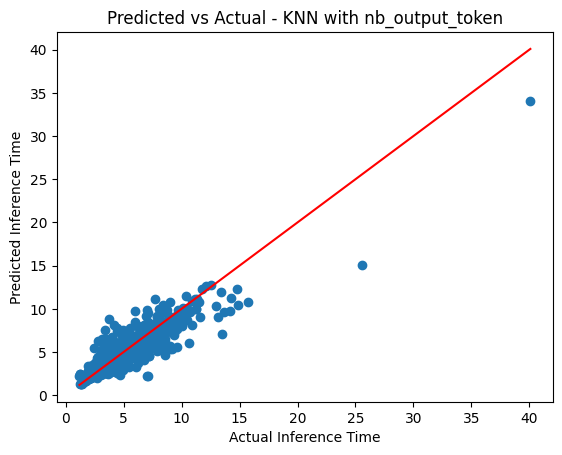

In [ ]:
plt.scatter(y_rfe_test, y_pred_knn_rfe)
plt.xlabel("Actual Inference Time")
plt.ylabel("Predicted Inference Time")
plt.title("Predicted vs Actual - KNN with nb_output_token")

plt.plot(
    [y_rfe_test.min(), y_rfe_test.max()],
    [y_rfe_test.min(), y_rfe_test.max()],
    color="red"
)

plt.show()

Most points are close to the red diagonal line, which means that the KNN model predicts inference time reasonably well for most observations.

the majority of observations are concentrated between about 2 and 10 seconds, and in this region the predictions follow the real values quite well. This is coherent with the good test performance.

For extreme values, the model still underestimates some large inference times. For example, observations with actual inference time around 25 to 40 seconds are predicted lower. So even KNN struggles with rare high-latency cases.

### 1.5.2 Residual plot

Residual = actual - predicted

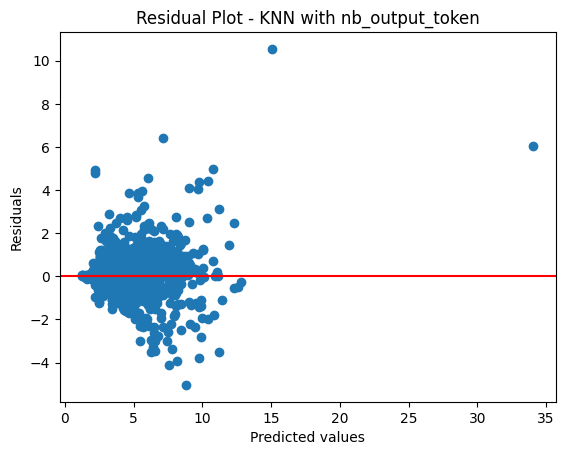

In [ ]:
residuals_knn_rfe = y_rfe_test - y_pred_knn_rfe

plt.scatter(y_pred_knn_rfe, residuals_knn_rfe)
plt.axhline(0, color="red")
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residual Plot - KNN with nb_output_token")
plt.show()

Most points are centered around the red horizontal line at 0. This is a good sign because it means the model does not have a strong systematic error for most observations.

However, the spread of residuals increases for larger predicted values. This means that the errors are not perfectly constant across all ranges of prediction. There are also some large positive residuals, meaning: actual value > predicted value so the model underestimated those observations.

## 2. Realistic/deployable model i.e. it uses only features known before inference.

Features used : nb_input_token, temperature, top_p, top_k, nb_user, gpu_fp32_tflops, gpu_num.

## Sequential Feature Selection with knn

In [ ]:
candidate_features_knn_without_output = [
    "nb_input_token",
    "temperature",
    "top_p",
    "top_k",
    "nb_user",
    "gpu_fp32_tflops",
    "gpu_memory_gib",
    "gpu_num"
]

X_train_knn_candidates_without_output = XWithoutGpuModelandOutputToken_train[candidate_features_knn_without_output]
X_test_knn_candidates_without_output = XWithoutGpuModelandOutputToken_test[candidate_features_knn_without_output]

target_train_knn_without_output = target_trainWithoutGpuModelandOutputToken
target_test_knn_without_output = target_testWithoutGpuModelandOutputToken

knn_selector_estimator_without_output = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(
        n_neighbors=10,
        metric="euclidean",
        weights="distance"
    ))
])

best_score_sfs_knn_without_output = -np.inf
best_features_sfs_knn_without_output = None
best_number_features_sfs_knn_without_output = None

n_total_features_without_output = X_train_knn_candidates_without_output.shape[1]

for n_features in range(1, n_total_features_without_output):

    sfs_knn_without_output = SequentialFeatureSelector(
        estimator=knn_selector_estimator_without_output,
        n_features_to_select=n_features,
        direction="forward",
        scoring="r2",
        cv=10,
        n_jobs=-1
    )

    sfs_knn_without_output.fit(
        X_train_knn_candidates_without_output,
        target_train_knn_without_output
    )

    selected_features_without_output = X_train_knn_candidates_without_output.columns[
        sfs_knn_without_output.get_support()
    ]

    scores_without_output = cross_val_score(
        knn_selector_estimator_without_output,
        X_train_knn_candidates_without_output[selected_features_without_output],
        target_train_knn_without_output,
        cv=10,
        scoring="r2",
        n_jobs=-1
    )

    mean_score_without_output = scores_without_output.mean()

    if mean_score_without_output > best_score_sfs_knn_without_output:
        best_score_sfs_knn_without_output = mean_score_without_output
        best_features_sfs_knn_without_output = selected_features_without_output
        best_number_features_sfs_knn_without_output = n_features

print("Best number of features for KNN without nb_output_token:", best_number_features_sfs_knn_without_output)
print("Best features for KNN without nb_output_token:", list(best_features_sfs_knn_without_output))
print("Best CV R2 for KNN feature selection without nb_output_token:", best_score_sfs_knn_without_output)

Best number of features for KNN without nb_output_token: 7
Best features for KNN without nb_output_token: ['nb_input_token', 'temperature', 'top_p', 'top_k', 'nb_user', 'gpu_fp32_tflops', 'gpu_num']
Best CV R2 for KNN feature selection without nb_output_token: 0.4065300502344208


For KNN specifically, the best feature subset without output length uses :  
- request size      → nb_input_token
- decoding settings → temperature, top_p, top_k
- system load       → nb_user
- hardware info     → gpu_fp32_tflops, gpu_num

The model did not select gpu_memory_gib, probably because its information is already mostly captured by the other GPU variables.

### 2.1 Cross validation

In [ ]:
selected_features_Knn_NoOutToken = [
    "nb_input_token",
    "temperature",
    "top_p",
    "top_k",
    "nb_user",
    "gpu_fp32_tflops",
    "gpu_num"
]

X_train_Knn_NoOutToken = XWithoutGpuModelandOutputToken_train[selected_features_Knn_NoOutToken]
X_test_Knn_NoOutToken = XWithoutGpuModelandOutputToken_test[selected_features_Knn_NoOutToken]

y_train_Knn_NoOutToken = target_trainWithoutGpuModelandOutputToken
y_test_Knn_NoOutToken = target_testWithoutGpuModelandOutputToken

k_values = range(1, 21)
distances = ["euclidean", "manhattan", "minkowski", "mahalanobis"]

cv = KFold(n_splits=10, shuffle=True, random_state=42)

best_score_Knn_NoOutToken = -np.inf
best_params_Knn_NoOutToken = None

for metric_Knn_NoOutToken in distances:
    for k_Knn_NoOutToken in k_values:

        fold_scores_Knn_NoOutToken = []

        for train_idx, val_idx in cv.split(X_train_Knn_NoOutToken):

            X_fold_train_Knn_NoOutToken = X_train_Knn_NoOutToken.iloc[train_idx]
            X_fold_val_Knn_NoOutToken = X_train_Knn_NoOutToken.iloc[val_idx]

            y_fold_train_Knn_NoOutToken = y_train_Knn_NoOutToken.iloc[train_idx]
            y_fold_val_Knn_NoOutToken = y_train_Knn_NoOutToken.iloc[val_idx]

            scaler_Knn_NoOutToken = StandardScaler()

            X_fold_train_scaled_Knn_NoOutToken = scaler_Knn_NoOutToken.fit_transform(
                X_fold_train_Knn_NoOutToken
            )

            X_fold_val_scaled_Knn_NoOutToken = scaler_Knn_NoOutToken.transform(
                X_fold_val_Knn_NoOutToken
            )

            if metric_Knn_NoOutToken == "mahalanobis":

                covariance_matrix_Knn_NoOutToken = np.cov(
                    X_fold_train_scaled_Knn_NoOutToken,
                    rowvar=False
                )

                inverse_covariance_matrix_Knn_NoOutToken = np.linalg.pinv(
                    covariance_matrix_Knn_NoOutToken
                )

                model_Knn_NoOutToken = KNeighborsRegressor(
                    n_neighbors=k_Knn_NoOutToken,
                    metric="mahalanobis",
                    metric_params={"VI": inverse_covariance_matrix_Knn_NoOutToken},
                    weights="distance"
                )

            elif metric_Knn_NoOutToken == "minkowski":

                model_Knn_NoOutToken = KNeighborsRegressor(
                    n_neighbors=k_Knn_NoOutToken,
                    metric="minkowski",
                    p=3,
                    weights="distance"
                )

            else:

                model_Knn_NoOutToken = KNeighborsRegressor(
                    n_neighbors=k_Knn_NoOutToken,
                    metric=metric_Knn_NoOutToken,
                    weights="distance"
                )

            model_Knn_NoOutToken.fit(
                X_fold_train_scaled_Knn_NoOutToken,
                y_fold_train_Knn_NoOutToken
            )

            y_fold_pred_Knn_NoOutToken = model_Knn_NoOutToken.predict(
                X_fold_val_scaled_Knn_NoOutToken
            )

            fold_score_Knn_NoOutToken = r2_score(
                y_fold_val_Knn_NoOutToken,
                y_fold_pred_Knn_NoOutToken
            )

            fold_scores_Knn_NoOutToken.append(fold_score_Knn_NoOutToken)

        mean_score_Knn_NoOutToken = np.mean(fold_scores_Knn_NoOutToken)

        if mean_score_Knn_NoOutToken > best_score_Knn_NoOutToken:
            best_score_Knn_NoOutToken = mean_score_Knn_NoOutToken
            best_params_Knn_NoOutToken = (k_Knn_NoOutToken, metric_Knn_NoOutToken)

print("Best k and metric:", best_params_Knn_NoOutToken)
print("Best CV R2:", best_score_Knn_NoOutToken)

Best k and metric: (20, 'minkowski')
Best CV R2: 0.40669677370715174


Cross-validation selected 20 neighbors with Minkowski distance as the best KNN configuration for the realistic model without nb_output_token.

k = 20 means the model needs more neighbors to make stable predictions. Without nb_output_token, the data is noisier, so using more neighbors helps smooth the prediction.

### 2.2 The creation of knn model

In [ ]:
best_k_NoOutToken, best_metric_NoOutToken = best_params_Knn_NoOutToken

scaler_final_Knn_NoOutToken = StandardScaler()

X_train_scaled_Knn_NoOutToken = scaler_final_Knn_NoOutToken.fit_transform(
    X_train_Knn_NoOutToken
)

X_test_scaled_Knn_NoOutToken = scaler_final_Knn_NoOutToken.transform(
    X_test_Knn_NoOutToken
)

if best_metric_NoOutToken == "mahalanobis":

    covariance_matrix_final_Knn_NoOutToken = np.cov(
        X_train_scaled_Knn_NoOutToken,
        rowvar=False
    )

    inverse_covariance_matrix_final_Knn_NoOutToken = np.linalg.pinv(
        covariance_matrix_final_Knn_NoOutToken
    )

    final_model_NoOutToken = KNeighborsRegressor(
        n_neighbors=best_k_NoOutToken,
        metric="mahalanobis",
        metric_params={"VI": inverse_covariance_matrix_final_Knn_NoOutToken},
        weights="distance"
    )

elif best_metric_NoOutToken == "minkowski":

    final_model_NoOutToken = KNeighborsRegressor(
        n_neighbors=best_k_NoOutToken,
        metric="minkowski",
        p=3,
        weights="distance"
    )

else:

    final_model_NoOutToken = KNeighborsRegressor(
        n_neighbors=best_k_NoOutToken,
        metric=best_metric_NoOutToken,
        weights="distance"
    )

final_model_NoOutToken.fit(
    X_train_scaled_Knn_NoOutToken,
    y_train_Knn_NoOutToken
)

KNeighborsRegressor(n_neighbors=20, p=3, weights='distance')

### 2.3 Prediction

In [ ]:
y_pred_NoOutToken = final_model_NoOutToken.predict(X_test_scaled_Knn_NoOutToken)

### 2.4 Evaluation metrics

In [ ]:
mae_NoOutToken = mean_absolute_error(y_test_Knn_NoOutToken, y_pred_NoOutToken)
mse_NoOutToken = mean_squared_error(y_test_Knn_NoOutToken, y_pred_NoOutToken)
rmse_NoOutToken = np.sqrt(mse_NoOutToken)
r2_NoOutToken = r2_score(y_test_Knn_NoOutToken, y_pred_NoOutToken)

print("MAE of knn model without nb_output_token :", mae_NoOutToken)
print("MSE of knn model without nb_output_token :", mse_NoOutToken)
print("RMSE of knn model without nb_output_token :", rmse_NoOutToken)
print("R2 score of knn model without nb_output_token :", r2_NoOutToken)

MAE of knn model without nb_output_token : 0.9419911222789105
MSE of knn model without nb_output_token : 3.0183870297668025
RMSE of knn model without nb_output_token : 1.7373505776805103
R2 score of knn model without nb_output_token : 0.46182429582189266


The test R² is 0.462, meaning that the model explains about 46.2% of the variance in inference time on the test set.

The MAE is about 0.94 seconds, meaning that, on average, the prediction error is around 0.94 seconds.

Since the median inference time is about 4.08 seconds, the average error represents 23%. So the error is moderate, better than linear regression without nb_output_token, but still not small compared with a typical request duration.

The RMSE is 1.74 seconds, which is much higher than the MAE. This means that most predictions are reasonably close, but some large errors exist.

### 2.5 Visualizations of the results

### 2.5.1 Predicted vs actual values

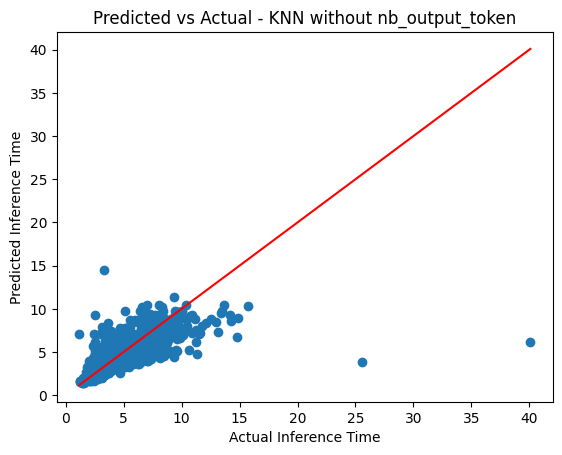

In [ ]:
plt.scatter(y_test_Knn_NoOutToken, y_pred_NoOutToken)

plt.xlabel("Actual Inference Time")
plt.ylabel("Predicted Inference Time")
plt.title("Predicted vs Actual - KNN without nb_output_token")

plt.plot(
    [y_test_Knn_NoOutToken.min(), y_test_Knn_NoOutToken.max()],
    [y_test_Knn_NoOutToken.min(), y_test_Knn_NoOutToken.max()],
    color="red"
)

plt.show()

Most points are concentrated in the common inference-time range, around 2 to 10 seconds. In this region, the model follows the general trend, but the points are more spread out than in the oracle KNN model.

The model does not predict extreme inference times well. For example, observations with actual inference time around 25 to 40 seconds are predicted much lower, around 4 to 6 seconds.

So the model strongly underestimates rare high inference times.

This happens because the model does not know nb_output_token. Without output length, it cannot easily distinguish between requests that look similar before inference but generate very different numbers of tokens.

### 2.5.2 Residual plot

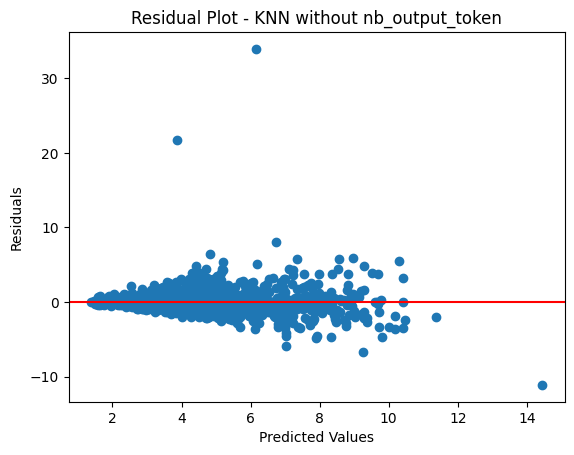

In [ ]:
residuals_NoOutToken = y_test_Knn_NoOutToken - y_pred_NoOutToken

plt.scatter(y_pred_NoOutToken, residuals_NoOutToken)
plt.axhline(y=0, color="red")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - KNN without nb_output_token")

plt.show()

Most residuals are close to zero, which means the model is reasonably accurate for many normal observations. However, the residual plot shows some very large positive residuals. Positive residuals mean : actual inference time > predicted inference time. So those points correspond to cases where the model underestimated inference time.

There is also one large negative residual, meaning the model overestimated one observation strongly.

The residual spread increases for higher predicted values, so the errors are not perfectly uniform. This suggests that the model still struggles with heterogeneity in inference time, especially extreme cases.

# **Third model : Neural network regression**

Neural network regression was used as a more flexible non-linear model. Unlike multiple linear regression, which mainly captures linear additive relationships when the original features are used directly, a neural network can learn more complex interactions between request-related variables, decoding parameters, and hardware characteristics. Therefore, in the realistic setting, the neural network is trained using all features available before inference, after removing nb_output_token and the redundant GPU model indicators.

## 1. Neural Network pipeline: scaling + neural network

In [ ]:
pipeline_nn_without_gpu_model_output_token = Pipeline([
    ("scaler_nn", StandardScaler()),
    ("model_nn", MLPRegressor(
        max_iter=1000,
        early_stopping=True,
        random_state=42
    ))
])

## 2. Hyperparameters to test for the neural network

In [ ]:
param_grid_nn_without_gpu_model_output_token = {
    "model_nn__hidden_layer_sizes": [
        (32,),
        (64,),
        (64, 32),
        (128, 64)
    ],
    "model_nn__activation": ["relu", "tanh"],
    "model_nn__alpha": [0.0001, 0.001, 0.01],
    "model_nn__learning_rate_init": [0.001, 0.0005]
}

Hidden layers  :

(32,)      → small/simple neural network

(64,)      → slightly larger model

(64, 32)   → medium model with two layers

(128, 64)  → larger model able to capture more complex patterns

Activation function :

relu → common default, efficient, often works well

tanh → smoother activation, can sometimes work better on scaled data

The activiation function that worked better is relu

For alpha :   

0.0001 → weak regularization

0.001  → moderate regularization

0.01   → stronger regularization

## 3. Cross-validation search

In [ ]:
grid_nn_without_gpu_model_output_token = GridSearchCV(
    estimator=pipeline_nn_without_gpu_model_output_token,
    param_grid=param_grid_nn_without_gpu_model_output_token,
    cv=10,
    scoring="r2",
    n_jobs=-1
)

grid_nn_without_gpu_model_output_token.fit(
    XWithoutGpuModelandOutputToken_train,
    target_trainWithoutGpuModelandOutputToken
)

print("Best Neural Network parameters:", grid_nn_without_gpu_model_output_token.best_params_)
print("Best Neural Network CV R2:", grid_nn_without_gpu_model_output_token.best_score_)

Best Neural Network parameters: {'model_nn__activation': 'relu', 'model_nn__alpha': 0.001, 'model_nn__hidden_layer_sizes': (64, 32), 'model_nn__learning_rate_init': 0.001}
Best Neural Network CV R2: 0.5204320874915112


The best neural network found by cross-validation has two hidden layers: (64,32).

The activation function is ReLU, which is commonly used because it helps neural networks learn non-linear relationships.

alpha = 0.001 is the regularization strength. It helps reduce overfitting by penalizing overly large weights.

The learning rate:0.001 controls how fast the model updates its weights during training.

Best Neural Network CV R2 = 0.5204 better than the realistic KNN CV R² ≈ 0.4067.

## 4. Best neural network model, prediction on test set and test evaluation

In [ ]:
best_nn_without_gpu_model_output_token = grid_nn_without_gpu_model_output_token.best_estimator_

y_pred_nn_without_gpu_model_output_token = best_nn_without_gpu_model_output_token.predict(
    XWithoutGpuModelandOutputToken_test
)

mae_nn_without_gpu_model_output_token = mean_absolute_error(
    target_testWithoutGpuModelandOutputToken,
    y_pred_nn_without_gpu_model_output_token
)

mse_nn_without_gpu_model_output_token = mean_squared_error(
    target_testWithoutGpuModelandOutputToken,
    y_pred_nn_without_gpu_model_output_token
)

rmse_nn_without_gpu_model_output_token = np.sqrt(mse_nn_without_gpu_model_output_token)

r2_nn_without_gpu_model_output_token = r2_score(
    target_testWithoutGpuModelandOutputToken,
    y_pred_nn_without_gpu_model_output_token
)

print("Neural Network Test MAE:", mae_nn_without_gpu_model_output_token)
print("Neural Network Test MSE:", mse_nn_without_gpu_model_output_token)
print("Neural Network Test RMSE:", rmse_nn_without_gpu_model_output_token)
print("Neural Network Test R2:", r2_nn_without_gpu_model_output_token)

Neural Network Test MAE: 0.9462049598106773
Neural Network Test MSE: 2.8381763572579572
Neural Network Test RMSE: 1.6846888013095942
Neural Network Test R2: 0.4939556973358168


The test R² is about 0.494, meaning that the neural network explains about 49.4% of the variance in inference time on unseen data.

The MAE is about 0.95 seconds. Since median inference time is about 4.08 seconds, this error represents 23.2%. So, on average, the model error is around 23% of a typical inference time.

The RMSE is 1.68 seconds, higher than the MAE. This means that most errors are moderate, but some large prediction errors still exist, especially for extreme inference-time cases.

## 5. Training evaluation to check overfitting

In [ ]:
y_train_pred_nn_without_gpu_model_output_token = best_nn_without_gpu_model_output_token.predict(
    XWithoutGpuModelandOutputToken_train
)

mae_train_nn_without_gpu_model_output_token = mean_absolute_error(
    target_trainWithoutGpuModelandOutputToken,
    y_train_pred_nn_without_gpu_model_output_token
)

rmse_train_nn_without_gpu_model_output_token = np.sqrt(
    mean_squared_error(
        target_trainWithoutGpuModelandOutputToken,
        y_train_pred_nn_without_gpu_model_output_token
    )
)

r2_train_nn_without_gpu_model_output_token = r2_score(
    target_trainWithoutGpuModelandOutputToken,
    y_train_pred_nn_without_gpu_model_output_token
)

print("Neural Network Train MAE:", mae_train_nn_without_gpu_model_output_token)
print("Neural Network Train RMSE:", rmse_train_nn_without_gpu_model_output_token)
print("Neural Network Train R2:", r2_train_nn_without_gpu_model_output_token)

Neural Network Train MAE: 0.9481811561750906
Neural Network Train RMSE: 1.5309923538864172
Neural Network Train R2: 0.5326944517686929


This small drop means the model generalizes reasonably well and there is no overfitting.

## 6.  Visualizations of the results

### 6.1 Predicted vs actual

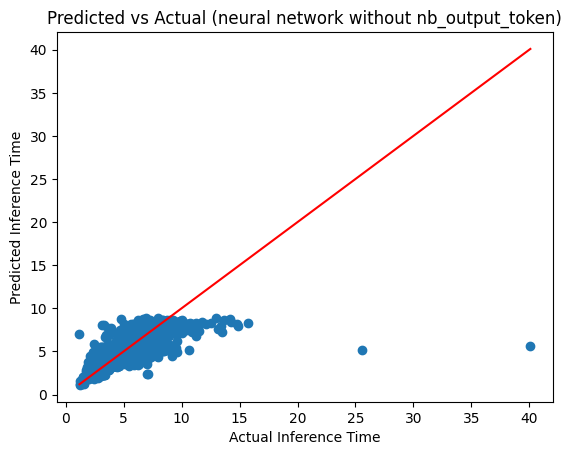

In [ ]:
plt.scatter(target_testWithoutGpuModelandOutputToken, y_pred_nn_without_gpu_model_output_token)

plt.xlabel("Actual Inference Time")
plt.ylabel("Predicted Inference Time")
plt.title("Predicted vs Actual (neural network without nb_output_token)")
plt.plot(
    [target_testWithoutGpuModelandOutputToken.min(), target_testWithoutGpuModelandOutputToken.max()],
    [target_testWithoutGpuModelandOutputToken.min(), target_testWithoutGpuModelandOutputToken.max()],
    color="red"
)

plt.show()

The neural network predicts common inference times reasonably well. Most points are concentrated in the usual range, around 2 to 10 seconds.

However, for large actual inference times, the model predicts much lower values. For example, requests with actual inference times around 25 to 40 seconds are predicted around 5 seconds.

So the neural network still underestimates extreme inference times.

This is expected because the model does not use nb_output_token. Without output length, it cannot know whether a request will generate a very long answer.

### 6.2 Residual plot

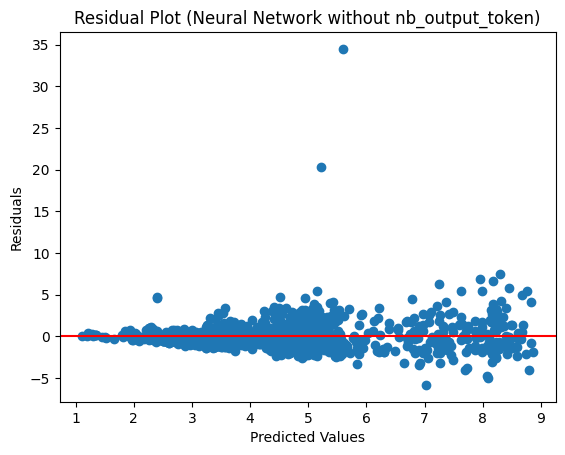

In [ ]:
residuals_nn_without_gpu_model_output_token = ( target_testWithoutGpuModelandOutputToken - y_pred_nn_without_gpu_model_output_token)

plt.scatter(y_pred_nn_without_gpu_model_output_token, residuals_nn_without_gpu_model_output_token)

plt.axhline(y=0, color="red")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (Neural Network without nb_output_token)")
plt.show()

Most residuals are close to zero, which means the model works reasonably well for normal requests. However, there are some large positive residuals (actual > predicted) so the model underestimated those observations.

The residual spread also increases for higher predicted values, showing that errors are not perfectly constant across all ranges.

# **Comparison between all models**

In [ ]:
results_4_models = pd.DataFrame({
    "Model": [
        "Multiple Linear Regression with nb_output_token",
        "K-Nearest Neighbors Regression with nb_output_token",
        "Multiple Linear Regression without nb_output_token",
        "K-Nearest Neighbors Regression without nb_output_token",
        "Neural network regression without nb_output_token"
    ],
    "Setting": [
        "Oracle",
        "Oracle",
        "Realistic",
        "Realistic",
        "Realistic"
    ],
    "MAE": [
        1.0679,
        0.6297,
        1.3155,
        0.9419,
        0.9462

    ],
    "MSE": [
        2.1729,
        1.0264,
        4.0282,
        3.0184,
        2.8382
    ],
    "RMSE": [
        1.4741,
        1.0131,
        2.0070,
        1.7374,
        1.6847
    ],
    "R2": [
        0.6126,
        0.8170,
        0.2817,
        0.4618,
        0.4940
    ]
})

results_4_models

,Model,Setting,MAE,MSE,RMSE,R2
0,Multiple Linear Regression with nb_output_token,Oracle,1.0679,2.1729,1.4741,0.6126
1,K-Nearest Neighbors Regression with nb_output_...,Oracle,0.6297,1.0264,1.0131,0.8170
2,Multiple Linear Regression without nb_output_t...,Realistic,1.3155,4.0282,2.0070,0.2817
3,K-Nearest Neighbors Regression without nb_outp...,Realistic,0.9419,3.0184,1.7374,0.4618
4,Neural network regression without nb_output_token,Realistic,0.9462,2.8382,1.6847,0.4940


The goal was to compare three levels of models: multiple linear regression as an interpretable linear baseline, K-Nearest Neighbors as a distance-based non-parametric method, and a neural network as a more flexible non-linear model. This comparison helps determine whether inference time is better modeled by simple linear effects, local similarity between requests, or more complex non-linear relationships.

The best overall performance is obtained by the oracle K-Nearest Neighbors model with nb_output_token, reaching an R² of 0.817 and a MAE of 0.63 seconds. This confirms that output length is a major predictor of inference time. However, this model is not deployable because nb_output_token is only known after generation.

In the realistic setting, where nb_output_token is removed, the neural network obtains the highest R², while K-Nearest Neighbors obtains a slightly lower MAE. Both models clearly outperform multiple linear regression, suggesting that inference time is better captured by non-linear or local relationships than by a simple linear additive model. Overall, the results show that realistic inference-time prediction is possible, but significantly harder without output-length information.

## Graph 1: MAE and RMSE comparison

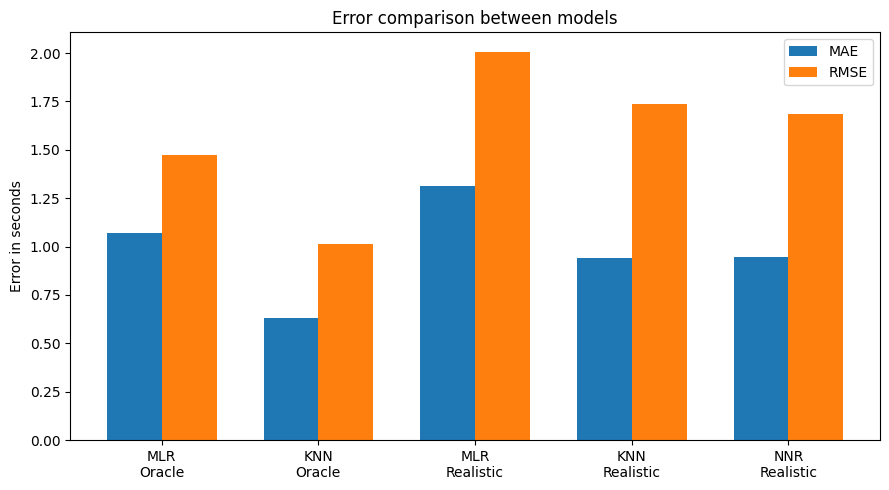

In [ ]:
results_plot = results_4_models.copy()

results_plot["Short Model"] = [
    "MLR\nOracle",
    "KNN\nOracle",
    "MLR\nRealistic",
    "KNN\nRealistic",
    "NNR\nRealistic"
]

x = np.arange(len(results_plot))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(x - width/2, results_plot["MAE"], width, label="MAE")
plt.bar(x + width/2, results_plot["RMSE"], width, label="RMSE")

plt.xticks(x, results_plot["Short Model"])
plt.ylabel("Error in seconds")
plt.title("Error comparison between models")
plt.legend()
plt.tight_layout()

plt.savefig("model_error_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Graph 2: R² comparison

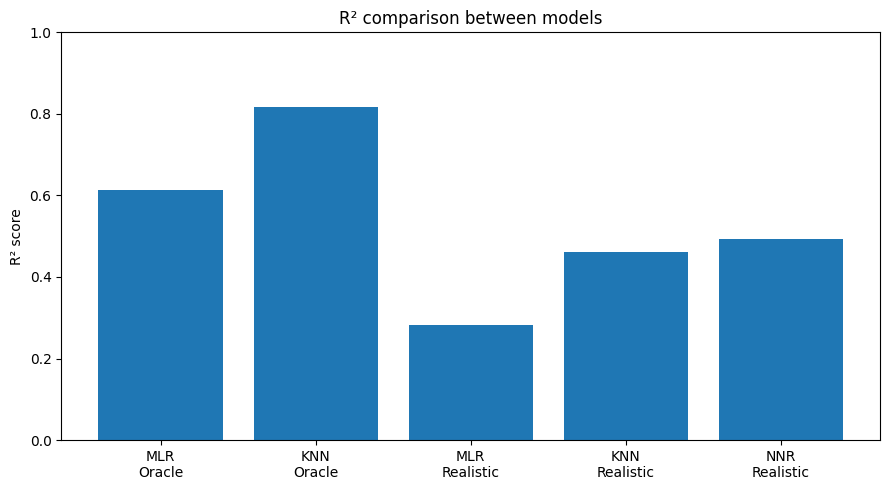

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(results_plot["Short Model"], results_plot["R2"])

plt.ylabel("R² score")
plt.title("R² comparison between models")
plt.ylim(0, 1)
plt.tight_layout()

plt.savefig("model_r2_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
results_plot = results_4_models.copy()

results_plot["Short Model"] = [
    "MLR\nOracle",
    "KNN\nOracle",
    "MLR\nRealistic",
    "KNN\nRealistic",
    "NNR\nRealistic"
]

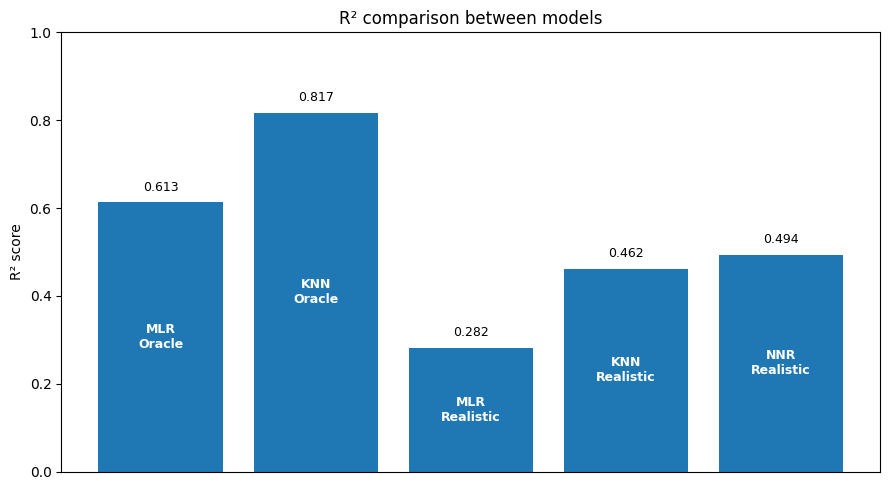

In [ ]:
plt.figure(figsize=(9, 5))

bars = plt.bar(results_plot["Short Model"], results_plot["R2"])

plt.ylabel("R² score")
plt.title("R² comparison between models")
plt.ylim(0, 1)

# Remove x-axis labels
plt.xticks([])

# Add model names inside bars and R² values above bars
for bar, model, value in zip(bars, results_plot["Short Model"], results_plot["R2"]):
    height = bar.get_height()

    # value above the bar
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

    # model name inside the bar
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height / 2,
        model,
        ha="center",
        va="center",
        fontsize=9,
        color="white",
        fontweight="bold"
    )

plt.tight_layout()
plt.savefig("model_r2_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

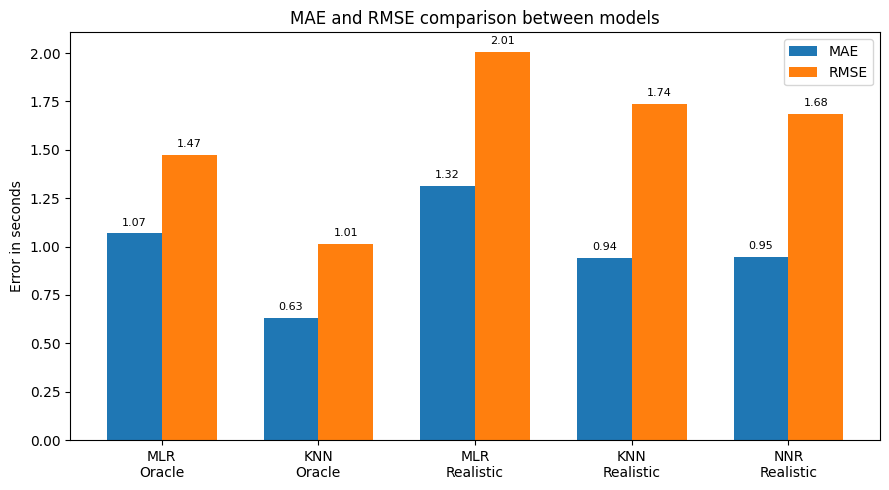

In [ ]:
x = np.arange(len(results_plot))
width = 0.35

plt.figure(figsize=(9, 5))

bars_mae = plt.bar(x - width/2, results_plot["MAE"], width, label="MAE")
bars_rmse = plt.bar(x + width/2, results_plot["RMSE"], width, label="RMSE")

plt.xticks(x, results_plot["Short Model"])
plt.ylabel("Error in seconds")
plt.title("MAE and RMSE comparison between models")
plt.legend()

# Add values above MAE bars
for bar in bars_mae:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.03,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

# Add values above RMSE bars
for bar in bars_rmse:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.03,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.savefig("model_error_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# Global conclusion

Overall, the results confirm that nb_output_token is the strongest predictor of inference time. Models using this variable reach the best performance, especially the oracle K-Nearest Neighbors model, but this setting is not directly deployable because output length is unknown before generation.

In the realistic setting, where only pre-inference features are available, prediction becomes harder. However, K-Nearest Neighbors and the neural network still achieve useful results and clearly outperform multiple linear regression. This suggests that inference time is better captured by local or non-linear relationships than by a simple linear additive model.

The main limitation is the prediction of extreme inference times. Rare high-latency requests are often underestimated, especially without output-length information. A natural next step would be to predict nb_output_token separately and use it as an additional estimated feature for inference-time prediction.